SOURCE

https://github.com/chenyuntc/simple-faster-rcnn-pytorch/tree/master

In [43]:
import pickle # Load refs and annotations
import json
import os
import pandas as pd
import numpy as np
import pprint
import json
import cv2
import random

from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.ops import roi_align
from torchvision.utils import draw_bounding_boxes
from torchvision import models
import torchmetrics

import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw

from ipywidgets import FloatProgress
import math 
from torch.nn.modules.batchnorm import _BatchNorm
from torchvision.ops import box_convert
from torchvision.ops import nms
from torchvision.ops import RoIPool

In [44]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


## UTILS

In [45]:
if torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

Neither CUDA or MPS backend are available. Resorting to CPU


In [46]:
log_dir = 'logs'

In [47]:
def plot_images(images):
    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

In [48]:
def draw_bboxes(image_path, bbox, gt, confidence):
    image = cv2.imread(image_path)

    # Define colors
    max_bbox_color = (0, 255, 0)  # Green for ground truth
    other_bbox_color = (0, 0, 255)  # Red for predictions

    # Plot all bboxes
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), other_bbox_color, 2)
    cv2.putText(image, 'Confiddence' + str(confidence), (int(bbox[0]), int(bbox[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, other_bbox_color, 2)
    color = max_bbox_color
    cv2.rectangle(image, (int(gt[0]), int(gt[1])) ,(int(gt[2]), int(gt[3])), color, 2)

    # Convert the image from BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image_rgb

In [49]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1) # +1 to avoid max(0,0) therefore avoiding 

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area

In [50]:
class MetricMeter:
    def __init__(self, name="Default", threshold = 0.5, log_dir='./logs/default_run'):
        self.name = name
        self.metrics = []
        self.epochs = []
        self.threshold = threshold
        self.reset()
        self.best_cases_iou = []  # To store the best cases
        self.worst_cases_iou = []
        self.best_cases_sim = []  # To store the best cases
        self.worst_cases_sim = []
        self.writer = SummaryWriter(log_dir=log_dir)

# TODO add SummaryWriter to plot

    def reset(self):
        self.count = 0
        self.iou = 0
        self.epoch = 0
        self.correct_bboxes, self.overall = 0,0
        self.semantic = 0
        self.metrics = []
    
    def add_best_iou(self, item):
        if len(self.best_cases_iou) < 5:
            self.best_cases_iou.append(item)
        else:
            min_best_case = min(self.best_cases_iou, key=lambda x: (x['iou']))
            if item['iou'] > min_best_case['iou']:
                self.best_cases_iou.remove(min_best_case)
                self.best_cases_iou.append(item)
    
    def add_worst_iou(self, item):
        if len(self.worst_cases_iou) < 5:
            self.worst_cases_iou.append(item)
        else:
            max_worst_case = max(self.worst_cases_iou, key=lambda x: (x['iou']))
            if (item['iou'] < max_worst_case['iou']):
                self.worst_cases_iou.remove(max_worst_case)
                self.worst_cases_iou.append(item)
    
    def add_best_confidence(self, item):
        if len(self.best_cases_sim) < 5:
            self.best_cases_sim.append(item)
        else:
            min_best_case = min(self.best_cases_sim, key=lambda x: (x['confidence']))
            if item['confidence'] > min_best_case['confidence']:
                self.best_cases_sim.remove(min_best_case)
                self.best_cases_sim.append(item)
    
    def add_worst_confidence(self, item):
        if len(self.worst_cases_sim) < 5:
            self.worst_cases_sim.append(item)
        else:
            max_worst_case = max(self.worst_cases_sim, key=lambda x: (x['confidence']))
            if (item['confidence'] < max_worst_case['confidence']):
                self.worst_cases_sim.remove(max_worst_case)
                self.worst_cases_sim.append(item)


    def update(self, iou, confidence,filename,bbox_e,bbox_gt):
        self.count += 1
        self.iou += iou
        if(iou >= self.threshold):
            self.correct_bboxes += 1
        self.semantic += confidence

        iteration = {
            'run_loc_acc': self.iou / self.count,
            'run_gro_acc': self.correct_bboxes / self.count,
            'run_sem_acc': self.semantic / self.count,
        }

        item = {
            'iou': iou,
            'confidence':confidence,
            'ground_truth': bbox_gt,
            'candidate': bbox_e,
            'path':filename
        }
        self.metrics.append([iteration])
        self.add_best_confidence(item)
        self.add_worst_confidence(item)
        self.add_best_iou(item)
        self.add_worst_iou(item)
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.count)
        self.writer.add_scalar('Grounding Accuracy',  self.correct_bboxes / self.count, self.count)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.count)

    def new_epoch(self):
        self.epoch += 1
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.epoch)
        self.writer.add_scalar('Grounding Accuracy',  self.correct_bboxes / self.count, self.epoch)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.epoch)
        self.epochs.append(self.metrics,self.best_cases_iou,self.best_cases_sim,self.worst_cases_iou,self.worst_cases_sim)
        self.reset()

    def __repr__(self):
        text = f"{self.name}: {self.avg:.8f}"
        return text
    
    def print_iteration(self):
        print(f"Localization accuracy = {self.iou / self.count}, Grounding Accuracy = {self.correct_bboxes / self.count}, Semantic Similarity = {self.semantic / self.count}")

    def get_best_iou_cases(self):
        return sorted(self.best_cases_iou, key=lambda x: x['iou'], reverse=True)

    def get_worst_iou_cases(self):
        return sorted(self.worst_cases_iou, key=lambda x: x['iou'])

    def get_best_pred_cases(self):
        return sorted(self.best_cases_sim, key=lambda x: x['confidence'], reverse=True)

    def get_worst_pred_cases(self):
        return sorted(self.worst_cases_sim, key=lambda x: x['confidence'])
    
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

In [51]:
with open("./refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("./refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

In [52]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [53]:
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3)
    denormalized_image = image * std + mean
    return denormalized_image

In [54]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


In [55]:
class Denormalize:
    def __init__(self):
        clip_mean = [0.48145466, 0.4578275, 0.40821073]
        clip_std = [0.26862954, 0.26130258, 0.27577711]
        self.mean = torch.tensor(clip_mean).reshape(-1, 1, 1)  # Adjust shape to (H, W, C)
        self.std = torch.tensor(clip_std).reshape(-1, 1, 1)

    def __call__(self, tensor):
        # Denormalize the image tensor
        denormalized_tensor = tensor * self.std + self.mean
        return denormalized_tensor

In [56]:
class DataAugmentation():
# This class is used to perform tranformation in order to have augmented data
    
    def blur(self,img,bbox):
        # Gaussian Blur the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.GaussianBlur(kernel_size=5),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def rotate(self,img,bbox):
        # Rotate the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomRotation(degrees=20),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    
    def grayscale(self,img,bbox):
        # Convert the image to grayscale
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Grayscale(num_output_channels=3),
            v2.ToTensor(),
            # since we do another manipulation we compute again the normalization 
            # of the image even tho clip does it before
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    
    def colorrand(self,img,bbox):
        # Randomly change the color of the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.ColorJitter(brightness=0.01*random.randrange(1,50), contrast=0.01*random.randrange(1,50), saturation=0.01*random.randrange(1,50), hue=0.01*random.randrange(1,50)),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    
    def Hflip(self,img,bbox):
        # flip horizontally both image and bbox
        #img = v2.functional.hflip(img)
        cxcywh_format = box_convert(bbox, 'xyxy', 'cxcywh')

        # flip the y coordinate
        transform = v2.Compose([
            v2.PILToTensor(),
            #Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomHorizontalFlip(p=1),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        cxcywh_format[0] = img.shape[2] - cxcywh_format[0]

        bbox = box_convert(cxcywh_format, 'cxcywh', 'xyxy')
        return img, bbox

    def random_augmentation(self,img,bbox):
        # Randomly choose a transformation to be applied to the image
        n = random.randint(0, 4)
        if n == 0:
            return DataAugmentation.blur(self,img,bbox)
        elif n == 1:
            return DataAugmentation.Hflip(self,img,bbox)
        elif n == 2:
            return DataAugmentation.grayscale(self,img,bbox)
        elif n == 3:
            return DataAugmentation.colorrand(self,img,bbox)
        else:
            return DataAugmentation.Hflip(self,img,bbox)

In [57]:
clip_model, clip_preprocess = clip.load("RN50", device=device)

In [58]:

class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name': 
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x 
                - y
                - width 
                - height
        }
    """
    def __init__(self, refs, model, preprocess, annotations, split="train", device = 'cuda', count = 5000):
        
        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        self.images = []
        self.texts = []
        self.filepaths =[]
        self.gt = []
        self.cls = []
        temp = 0
        for elem in [d for d in refs if d["split"]==split]:
            
            # Retrieve Single image
            file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tnsor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tnsor, 'xywh', 'xyxy')
            # Get all texts related to the picture
            sentences = elem['sentences']
            # for i in sentences:
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            self.images.append(self.clip_preprocess(image))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            # temp += 1
            # if (temp > count):
            #     break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        images = self.images[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        return text, images, gt, cls, filename

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


The RefCOCOG_noproc is the dataset used in our locacl machines due to the restricted RAM size

In [59]:
class RefCOCOG_noproc(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name': 
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x 
                - y
                - width 
                - height
        }
    """
    def __init__(self, refs, model, preprocess, annotations, split="train", device = 'cuda', count = 5000):
        
        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        #self.images = []
        self.raws = []
        self.texts = []
        self.filepaths =[]
        self.gt = []
        self.cls = []
        self.AUG = DataAugmentation()


        temp = 0
        for elem in [d for d in refs if d["split"]==split]:
            
            # Retrieve Single image
            file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            #image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tnsor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tnsor, 'xywh', 'xyxy')
            # Get all texts related to the picture
            sentences = elem['sentences']
            # for i in sentences:
            self.raws.append(sentences[0]['raw'])
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            #self.images.append(self.clip_preprocess(image))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            temp += 1
            if (temp > count):
                break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        raw = self.raws[idx]
        text = self.texts[idx]
        #images = self.images[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        image = Image.open(filename)
        original_height = image.size[1]
        #self.clip_preprocess(image)
        # Apply augmentations
        image = self.clip_preprocess(image).to(device)
        image, gt = self.AUG.random_augmentation(image,gt)
        processed_height = image.size(-2)
        
        scale = processed_height / original_height
        
        #image = self.clip_preprocess(image).to(device)
        return raw, text, gt, cls, filename, image, scale

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [60]:
# create dataset and dataloader
print("----------------------Processing train split----------------------------")
dataset_train = RefCOCOG_noproc(refs, clip_model, clip_preprocess, annotations, device=device, split="train")
dataloader_train = DataLoader(dataset_train, batch_size=16)
len_train = len(dataset_train)
print(f"Numero esempi in train = {len_train}")

print("----------------------Processing test split-----------------------------")
dataset_test = RefCOCOG_noproc(refs, clip_model, clip_preprocess, annotations, device=device, split="test")
dataloader_test = DataLoader(dataset_test, batch_size=16)
len_test = len(dataset_test)
print(f"Numero esempi in test = {len_test}")

print("----------------------Processing eval split-----------------------------")
dataset_eval = RefCOCOG_noproc(refs, clip_model, clip_preprocess, annotations, device=device, split="val")
dataloader_eval = DataLoader(dataset_eval, batch_size=16)
len_eval = len(dataset_eval)
print(f"Numero esempi in eval = {len_eval}")

print("------------------------------------------------------------------------")


----------------------Processing train split----------------------------
Numero esempi in train = 5001
----------------------Processing test split-----------------------------
Numero esempi in test = 5001
----------------------Processing eval split-----------------------------
Numero esempi in eval = 2573
------------------------------------------------------------------------


In [61]:
images = []
for raw, text, gt, cls, filename, image, scale in dataloader_eval:
    images = image
    break

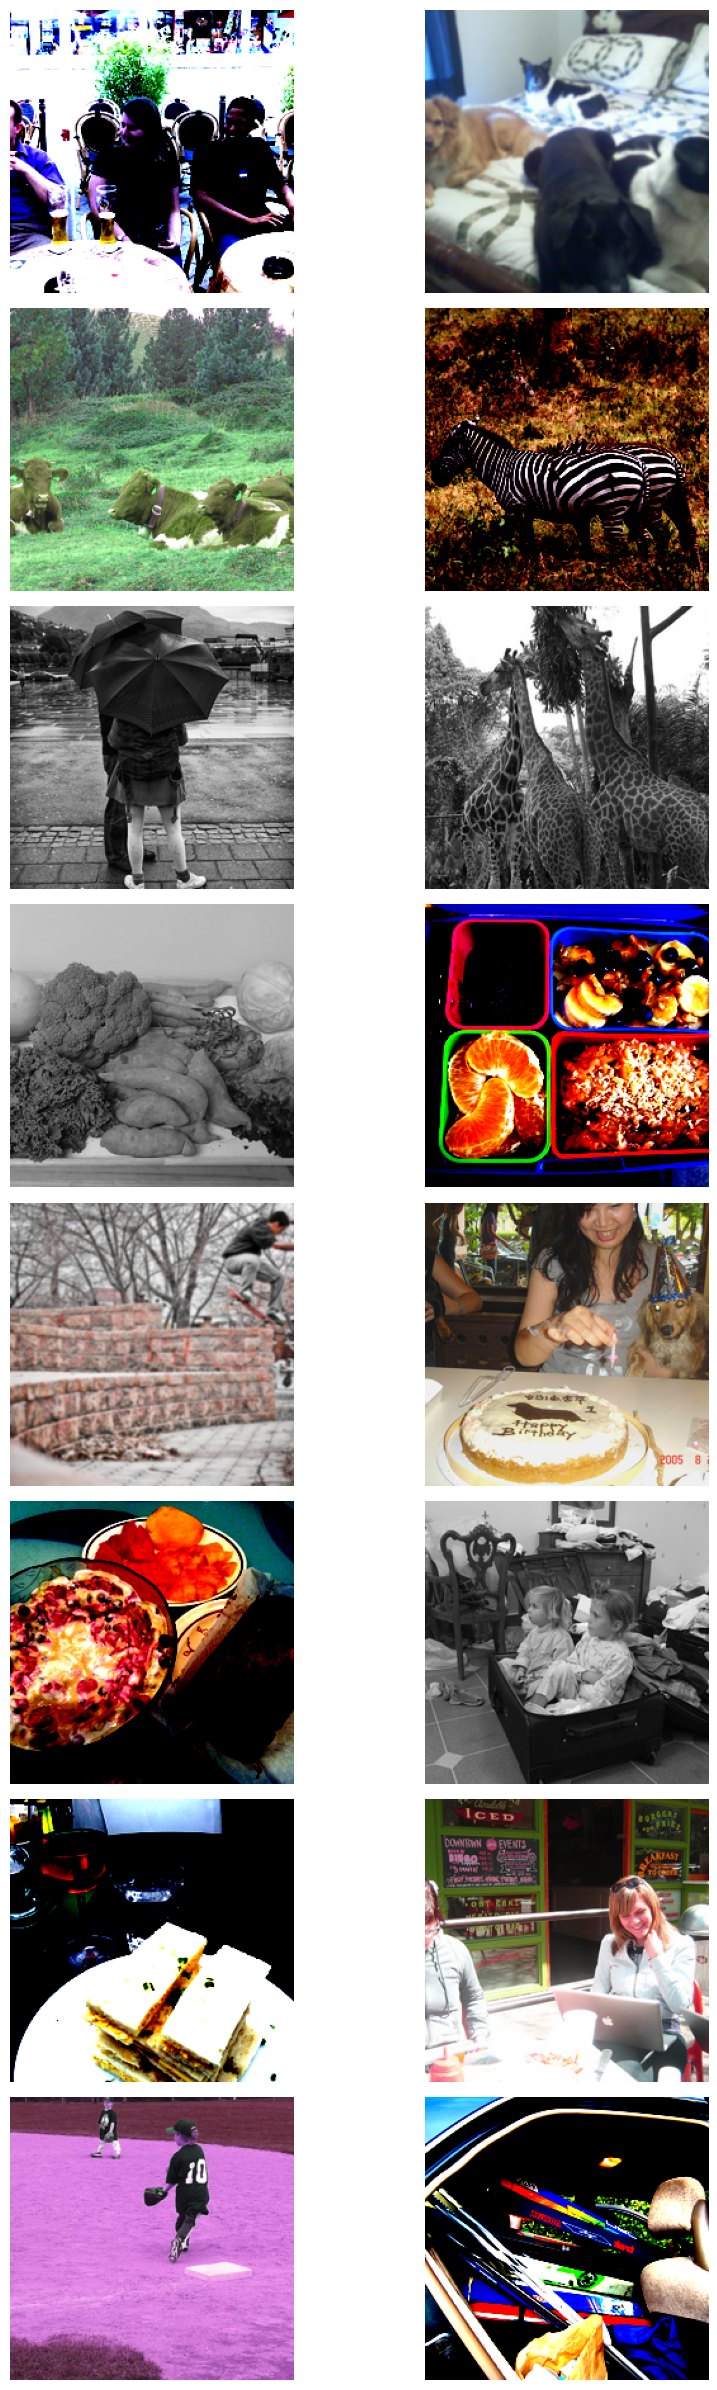

In [62]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Function to denormalize an image
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3)
    denormalized_image = image * std + mean
    return denormalized_image
# Calculate the number of rows needed to display images in a 2-column layout
num_images = len(images)
num_cols = 2
num_rows = (num_images + num_cols - 1) // num_cols  # Ceiling division to get the required number of rows

# Set up the plot
plt.figure(figsize=(10, num_rows * 3))  # Adjust the figure size as needed

# Loop through and display each processed image in a grid with denormalization
for i, img in enumerate(images):
    # Denormalize the image
    img = img.permute(1, 2, 0)  # Convert (C, H, W) to (H, W, C)
    img = denormalize(img, mean, std)  # Apply denormalization
    img = torch.clip(img, 0, 1).numpy()  # Clip to valid range [0, 1] and convert to numpy for display

    # Add subplot in a 2-column grid
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

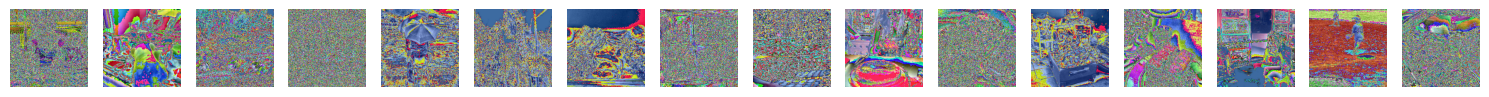

In [63]:
# Set up the plot
plt.figure(figsize=(15, 3))

# Loop through and display each processed image
for i, img in enumerate(images):
    # Check if the image is a tensor and convert it to a NumPy array if needed
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()  # Convert (C, H, W) to (H, W, C)
        img = (img * 255).astype('uint8')  # Convert to [0, 255] range for display

    # Add subplot
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

In [64]:
def tonumpy(data):
    if isinstance(data, np.ndarray):
        return data
    if isinstance(data, torch.Tensor):
        return data.detach().cpu().numpy()


def totensor(data, cuda=False):
    if isinstance(data, np.ndarray):
        tensor = torch.from_numpy(data)
    if isinstance(data, torch.Tensor):
        tensor = data.detach()
    if cuda:
        tensor = tensor.cuda()
    return tensor


def scalar(data):
    if isinstance(data, np.ndarray):
        return data.reshape(1)[0]
    if isinstance(data, torch.Tensor):
        return data.item()

In [65]:
def loc2bbox(src_bbox, loc):
    """Decode bounding boxes from bounding box offsets and scales.

    Given bounding box offsets and scales computed by
    :meth:`bbox2loc`, this function decodes the representation to
    coordinates in 2D image coordinates.

    Given scales and offsets :math:`t_y, t_x, t_h, t_w` and a bounding
    box whose center is :math:`(y, x) = p_y, p_x` and size :math:`p_h, p_w`,
    the decoded bounding box's center :math:`\\hat{g}_y`, :math:`\\hat{g}_x`
    and size :math:`\\hat{g}_h`, :math:`\\hat{g}_w` are calculated
    by the following formulas.

    * :math:`\\hat{g}_y = p_h t_y + p_y`
    * :math:`\\hat{g}_x = p_w t_x + p_x`
    * :math:`\\hat{g}_h = p_h \\exp(t_h)`
    * :math:`\\hat{g}_w = p_w \\exp(t_w)`

    The decoding formulas are used in works such as R-CNN [#]_.

    The output is same type as the type of the inputs.

    .. [#] Ross Girshick, Jeff Donahue, Trevor Darrell, Jitendra Malik. \
    Rich feature hierarchies for accurate object detection and semantic \
    segmentation. CVPR 2014.

    Args:
        src_bbox (array): A coordinates of bounding boxes.
            Its shape is :math:`(R, 4)`. These coordinates are
            :math:`p_{ymin}, p_{xmin}, p_{ymax}, p_{xmax}`.
        loc (array): An array with offsets and scales.
            The shapes of :obj:`src_bbox` and :obj:`loc` should be same.
            This contains values :math:`t_y, t_x, t_h, t_w`.

    Returns:
        array:
        Decoded bounding box coordinates. Its shape is :math:`(R, 4)`. \
        The second axis contains four values \
        :math:`\\hat{g}_{ymin}, \\hat{g}_{xmin},
        \\hat{g}_{ymax}, \\hat{g}_{xmax}`.

    """

    if src_bbox.shape[0] == 0:
        return np.zeros((0, 4), dtype=loc.dtype)

    src_bbox = src_bbox.astype(src_bbox.dtype, copy=False)

    src_height = src_bbox[:, 2] - src_bbox[:, 0]
    src_width = src_bbox[:, 3] - src_bbox[:, 1]
    src_ctr_y = src_bbox[:, 0] + 0.5 * src_height
    src_ctr_x = src_bbox[:, 1] + 0.5 * src_width

    dy = loc[:, 0::4]
    dx = loc[:, 1::4]
    dh = loc[:, 2::4]
    dw = loc[:, 3::4]

    ctr_y = dy * src_height[:, np.newaxis] + src_ctr_y[:, np.newaxis]
    ctr_x = dx * src_width[:, np.newaxis] + src_ctr_x[:, np.newaxis]
    h = np.exp(dh) * src_height[:, np.newaxis]
    w = np.exp(dw) * src_width[:, np.newaxis]

    dst_bbox = np.zeros(loc.shape, dtype=loc.dtype)
    dst_bbox[:, 0::4] = ctr_y - 0.5 * h
    dst_bbox[:, 1::4] = ctr_x - 0.5 * w
    dst_bbox[:, 2::4] = ctr_y + 0.5 * h
    dst_bbox[:, 3::4] = ctr_x + 0.5 * w

    return dst_bbox


def bbox2loc(src_bbox, dst_bbox):
    """Encodes the source and the destination bounding boxes to "loc".

    Given bounding boxes, this function computes offsets and scales
    to match the source bounding boxes to the target bounding boxes.
    Mathematcially, given a bounding box whose center is
    :math:`(y, x) = p_y, p_x` and
    size :math:`p_h, p_w` and the target bounding box whose center is
    :math:`g_y, g_x` and size :math:`g_h, g_w`, the offsets and scales
    :math:`t_y, t_x, t_h, t_w` can be computed by the following formulas.

    * :math:`t_y = \\frac{(g_y - p_y)} {p_h}`
    * :math:`t_x = \\frac{(g_x - p_x)} {p_w}`
    * :math:`t_h = \\log(\\frac{g_h} {p_h})`
    * :math:`t_w = \\log(\\frac{g_w} {p_w})`

    The output is same type as the type of the inputs.
    The encoding formulas are used in works such as R-CNN [#]_.

    .. [#] Ross Girshick, Jeff Donahue, Trevor Darrell, Jitendra Malik. \
    Rich feature hierarchies for accurate object detection and semantic \
    segmentation. CVPR 2014.

    Args:
        src_bbox (array): An image coordinate array whose shape is
            :math:`(R, 4)`. :math:`R` is the number of bounding boxes.
            These coordinates are
            :math:`p_{ymin}, p_{xmin}, p_{ymax}, p_{xmax}`.
        dst_bbox (array): An image coordinate array whose shape is
            :math:`(R, 4)`.
            These coordinates are
            :math:`g_{ymin}, g_{xmin}, g_{ymax}, g_{xmax}`.

    Returns:
        array:
        Bounding box offsets and scales from :obj:`src_bbox` \
        to :obj:`dst_bbox`. \
        This has shape :math:`(R, 4)`.
        The second axis contains four values :math:`t_y, t_x, t_h, t_w`.

    """

    height = src_bbox[:, 2] - src_bbox[:, 0]
    width = src_bbox[:, 3] - src_bbox[:, 1]
    ctr_y = src_bbox[:, 0] + 0.5 * height
    ctr_x = src_bbox[:, 1] + 0.5 * width

    base_height = dst_bbox[:, 2] - dst_bbox[:, 0]
    base_width = dst_bbox[:, 3] - dst_bbox[:, 1]
    base_ctr_y = dst_bbox[:, 0] + 0.5 * base_height
    base_ctr_x = dst_bbox[:, 1] + 0.5 * base_width

    eps = np.finfo(height.dtype).eps
    height = np.maximum(height, eps)
    width = np.maximum(width, eps)

    dy = (base_ctr_y - ctr_y) / height
    dx = (base_ctr_x - ctr_x) / width
    dh = np.log(base_height / height)
    dw = np.log(base_width / width)

    loc = np.vstack((dy, dx, dh, dw)).transpose()
    return loc


def bbox_iou(bbox_a, bbox_b):
    """Calculate the Intersection of Unions (IoUs) between bounding boxes.

    IoU is calculated as a ratio of area of the intersection
    and area of the union.

    This function accepts both :obj:`numpy.ndarray` and :obj:`cupy.ndarray` as
    inputs. Please note that both :obj:`bbox_a` and :obj:`bbox_b` need to be
    same type.
    The output is same type as the type of the inputs.

    Args:
        bbox_a (array): An array whose shape is :math:`(N, 4)`.
            :math:`N` is the number of bounding boxes.
            The dtype should be :obj:`numpy.float32`.
        bbox_b (array): An array similar to :obj:`bbox_a`,
            whose shape is :math:`(K, 4)`.
            The dtype should be :obj:`numpy.float32`.

    Returns:
        array:
        An array whose shape is :math:`(N, K)`. \
        An element at index :math:`(n, k)` contains IoUs between \
        :math:`n` th bounding box in :obj:`bbox_a` and :math:`k` th bounding \
        box in :obj:`bbox_b`.

    """
    if bbox_a.shape[1] != 4 or bbox_b.shape[1] != 4:
        raise IndexError

    # top left
    tl = np.maximum(bbox_a[:, None, :2], bbox_b[:, :2])
    # bottom right
    br = np.minimum(bbox_a[:, None, 2:], bbox_b[:, 2:])

    area_i = np.prod(br - tl, axis=2) * (tl < br).all(axis=2)
    area_a = np.prod(bbox_a[:, 2:] - bbox_a[:, :2], axis=1)
    area_b = np.prod(bbox_b[:, 2:] - bbox_b[:, :2], axis=1)
    return area_i / (area_a[:, None] + area_b - area_i)


def __test():
    pass


if __name__ == '__main__':
    __test()


def generate_anchor_base(base_size=16, ratios=[0.5, 1, 2],
                         anchor_scales=[8, 16, 32]):
    """Generate anchor base windows by enumerating aspect ratio and scales.

    Generate anchors that are scaled and modified to the given aspect ratios.
    Area of a scaled anchor is preserved when modifying to the given aspect
    ratio.

    :obj:`R = len(ratios) * len(anchor_scales)` anchors are generated by this
    function.
    The :obj:`i * len(anchor_scales) + j` th anchor corresponds to an anchor
    generated by :obj:`ratios[i]` and :obj:`anchor_scales[j]`.

    For example, if the scale is :math:`8` and the ratio is :math:`0.25`,
    the width and the height of the base window will be stretched by :math:`8`.
    For modifying the anchor to the given aspect ratio,
    the height is halved and the width is doubled.

    Args:
        base_size (number): The width and the height of the reference window.
        ratios (list of floats): This is ratios of width to height of
            the anchors.
        anchor_scales (list of numbers): This is areas of anchors.
            Those areas will be the product of the square of an element in
            :obj:`anchor_scales` and the original area of the reference
            window.

    Returns:
        ~numpy.ndarray:
        An array of shape :math:`(R, 4)`.
        Each element is a set of coordinates of a bounding box.
        The second axis corresponds to
        :math:`(y_{min}, x_{min}, y_{max}, x_{max})` of a bounding box.

    """
    py = base_size / 2.
    px = base_size / 2.

    anchor_base = np.zeros((len(ratios) * len(anchor_scales), 4),
                           dtype=np.float32)
    for i in range(len(ratios)):
        for j in range(len(anchor_scales)):
            h = base_size * anchor_scales[j] * np.sqrt(ratios[i])
            w = base_size * anchor_scales[j] * np.sqrt(1. / ratios[i])

            index = i * len(anchor_scales) + j
            anchor_base[index, 0] = py - h / 2.
            anchor_base[index, 1] = px - w / 2.
            anchor_base[index, 2] = py + h / 2.
            anchor_base[index, 3] = px + w / 2.
    return anchor_base

In [66]:
class ProposalTargetCreator(object):
    """Assign ground truth bounding boxes to given RoIs.

    The :meth:`__call__` of this class generates training targets
    for each object proposal.
    This is used to train Faster RCNN [#]_.

    .. [#] Shaoqing Ren, Kaiming He, Ross Girshick, Jian Sun. \
    Faster R-CNN: Towards Real-Time Object Detection with \
    Region Proposal Networks. NIPS 2015.

    Args:
        n_sample (int): The number of sampled regions.
        pos_ratio (float): Fraction of regions that is labeled as a
            foreground.
        pos_iou_thresh (float): IoU threshold for a RoI to be considered as a
            foreground.
        neg_iou_thresh_hi (float): RoI is considered to be the background
            if IoU is in
            [:obj:`neg_iou_thresh_hi`, :obj:`neg_iou_thresh_hi`).
        neg_iou_thresh_lo (float): See above.

    """

    def __init__(self,
                 n_sample=128,
                 pos_ratio=0.25, pos_iou_thresh=0.5,
                 neg_iou_thresh_hi=0.5, neg_iou_thresh_lo=0.0
                 ):
        self.n_sample = n_sample
        self.pos_ratio = pos_ratio
        self.pos_iou_thresh = pos_iou_thresh
        self.neg_iou_thresh_hi = neg_iou_thresh_hi
        self.neg_iou_thresh_lo = neg_iou_thresh_lo  # NOTE:default 0.1 in py-faster-rcnn

    def __call__(self, roi, bbox, label,
                 loc_normalize_mean=(0., 0., 0., 0.),
                 loc_normalize_std=(0.1, 0.1, 0.2, 0.2)):
        """Assigns ground truth to sampled proposals.

        This function samples total of :obj:`self.n_sample` RoIs
        from the combination of :obj:`roi` and :obj:`bbox`.
        The RoIs are assigned with the ground truth class labels as well as
        bounding box offsets and scales to match the ground truth bounding
        boxes. As many as :obj:`pos_ratio * self.n_sample` RoIs are
        sampled as foregrounds.

        Offsets and scales of bounding boxes are calculated using
        :func:`model.utils.bbox_tools.bbox2loc`.
        Also, types of input arrays and output arrays are same.

        Here are notations.

        * :math:`S` is the total number of sampled RoIs, which equals \
            :obj:`self.n_sample`.
        * :math:`L` is number of object classes possibly including the \
            background.

        Args:
            roi (array): Region of Interests (RoIs) from which we sample.
                Its shape is :math:`(R, 4)`
            bbox (array): The coordinates of ground truth bounding boxes.
                Its shape is :math:`(R', 4)`.
            label (array): Ground truth bounding box labels. Its shape
                is :math:`(R',)`. Its range is :math:`[0, L - 1]`, where
                :math:`L` is the number of foreground classes.
            loc_normalize_mean (tuple of four floats): Mean values to normalize
                coordinates of bouding boxes.
            loc_normalize_std (tupler of four floats): Standard deviation of
                the coordinates of bounding boxes.

        Returns:
            (array, array, array):

            * **sample_roi**: Regions of interests that are sampled. \
                Its shape is :math:`(S, 4)`.
            * **gt_roi_loc**: Offsets and scales to match \
                the sampled RoIs to the ground truth bounding boxes. \
                Its shape is :math:`(S, 4)`.
            * **gt_roi_label**: Labels assigned to sampled RoIs. Its shape is \
                :math:`(S,)`. Its range is :math:`[0, L]`. The label with \
                value 0 is the background.

        """
        
        n_bbox = bbox.shape
        
        roi = np.concatenate((roi, bbox), axis=0)

        pos_roi_per_image = np.round(self.n_sample * self.pos_ratio)
        iou = bbox_iou(roi, bbox)
        gt_assignment = iou.argmax(axis=1)
        
        max_iou = iou.max(axis=1)
        
        # Offset range of classes from [0, n_fg_class - 1] to [1, n_fg_class].
        # The label with value 0 is the background.
        gt_roi_label = label[gt_assignment] + 1

        # Select foreground RoIs as those with >= pos_iou_thresh IoU.
        pos_index = np.where(max_iou >= self.pos_iou_thresh)[0]
        pos_roi_per_this_image = int(min(pos_roi_per_image, pos_index.size))
        if pos_index.size > 0:
            pos_index = np.random.choice(
                pos_index, size=pos_roi_per_this_image, replace=False)

        # Select background RoIs as those within
        # [neg_iou_thresh_lo, neg_iou_thresh_hi).
        neg_index = np.where((max_iou < self.neg_iou_thresh_hi) &
                             (max_iou >= self.neg_iou_thresh_lo))[0]
        neg_roi_per_this_image = self.n_sample - pos_roi_per_this_image
        neg_roi_per_this_image = int(min(neg_roi_per_this_image,
                                         neg_index.size))
        if neg_index.size > 0:
            neg_index = np.random.choice(
                neg_index, size=neg_roi_per_this_image, replace=False)

        # The indices that we're selecting (both positive and negative).
        keep_index = np.append(pos_index, neg_index)
        gt_roi_label = gt_roi_label[keep_index]
        gt_roi_label[pos_roi_per_this_image:] = 0  # negative labels --> 0
        sample_roi = roi[keep_index]

        # Compute offsets and scales to match sampled RoIs to the GTs.
        gt_roi_loc = bbox2loc(sample_roi, bbox[gt_assignment[keep_index]])
        gt_roi_loc = ((gt_roi_loc - np.array(loc_normalize_mean, np.float32)
                       ) / np.array(loc_normalize_std, np.float32))

        return sample_roi, gt_roi_loc, gt_roi_label


class AnchorTargetCreator(object):
    """Assign the ground truth bounding boxes to anchors.

    Assigns the ground truth bounding boxes to anchors for training Region
    Proposal Networks introduced in Faster R-CNN [#]_.

    Offsets and scales to match anchors to the ground truth are
    calculated using the encoding scheme of
    :func:`model.utils.bbox_tools.bbox2loc`.

    .. [#] Shaoqing Ren, Kaiming He, Ross Girshick, Jian Sun. \
    Faster R-CNN: Towards Real-Time Object Detection with \
    Region Proposal Networks. NIPS 2015.

    Args:
        n_sample (int): The number of regions to produce.
        pos_iou_thresh (float): Anchors with IoU above this
            threshold will be assigned as positive.
        neg_iou_thresh (float): Anchors with IoU below this
            threshold will be assigned as negative.
        pos_ratio (float): Ratio of positive regions in the
            sampled regions.

    """

    def __init__(self,
                 n_sample=256,
                 pos_iou_thresh=0.7, neg_iou_thresh=0.3,
                 pos_ratio=0.5):
        self.n_sample = n_sample
        self.pos_iou_thresh = pos_iou_thresh
        self.neg_iou_thresh = neg_iou_thresh
        self.pos_ratio = pos_ratio

    def __call__(self, bbox, anchor, img_size):
        """Assign ground truth supervision to sampled subset of anchors.

        Types of input arrays and output arrays are same.

        Here are notations.

        * :math:`S` is the number of anchors.
        * :math:`R` is the number of bounding boxes.

        Args:
            bbox (array): Coordinates of bounding boxes. Its shape is
                :math:`(R, 4)`.
            anchor (array): Coordinates of anchors. Its shape is
                :math:`(S, 4)`.
            img_size (tuple of ints): A tuple :obj:`H, W`, which
                is a tuple of height and width of an image.

        Returns:
            (array, array):

            #NOTE: it's scale not only  offset
            * **loc**: Offsets and scales to match the anchors to \
                the ground truth bounding boxes. Its shape is :math:`(S, 4)`.
            * **label**: Labels of anchors with values \
                :obj:`(1=positive, 0=negative, -1=ignore)`. Its shape \
                is :math:`(S,)`.

        """

        img_H, img_W = img_size

        n_anchor = len(anchor)
        inside_index = _get_inside_index(anchor, img_H, img_W)
        anchor = anchor[inside_index]
        argmax_ious, label = self._create_label(
            inside_index, anchor, bbox)

        # compute bounding box regression targets
        loc = bbox2loc(anchor, bbox[argmax_ious])

        # map up to original set of anchors
        label = _unmap(label, n_anchor, inside_index, fill=-1)
        loc = _unmap(loc, n_anchor, inside_index, fill=0)

        return loc, label

    def _create_label(self, inside_index, anchor, bbox):
        # label: 1 is positive, 0 is negative, -1 is dont care
        label = np.empty((len(inside_index),), dtype=np.int32)
        label.fill(-1)

        argmax_ious, max_ious, gt_argmax_ious = \
            self._calc_ious(anchor, bbox, inside_index)

        # assign negative labels first so that positive labels can clobber them
        label[max_ious < self.neg_iou_thresh] = 0

        # positive label: for each gt, anchor with highest iou
        label[gt_argmax_ious] = 1

        # positive label: above threshold IOU
        label[max_ious >= self.pos_iou_thresh] = 1

        # subsample positive labels if we have too many
        n_pos = int(self.pos_ratio * self.n_sample)
        pos_index = np.where(label == 1)[0]
        if len(pos_index) > n_pos:
            disable_index = np.random.choice(
                pos_index, size=(len(pos_index) - n_pos), replace=False)
            label[disable_index] = -1

        # subsample negative labels if we have too many
        n_neg = self.n_sample - np.sum(label == 1)
        neg_index = np.where(label == 0)[0]
        if len(neg_index) > n_neg:
            disable_index = np.random.choice(
                neg_index, size=(len(neg_index) - n_neg), replace=False)
            label[disable_index] = -1

        return argmax_ious, label

    def _calc_ious(self, anchor, bbox, inside_index):
        # ious between the anchors and the gt boxes
        ious = bbox_iou(anchor, bbox)
        argmax_ious = ious.argmax(axis=1)
        max_ious = ious[np.arange(len(inside_index)), argmax_ious]
        gt_argmax_ious = ious.argmax(axis=0)
        gt_max_ious = ious[gt_argmax_ious, np.arange(ious.shape[1])]
        gt_argmax_ious = np.where(ious == gt_max_ious)[0]

        return argmax_ious, max_ious, gt_argmax_ious


def _unmap(data, count, index, fill=0):
    # Unmap a subset of item (data) back to the original set of items (of
    # size count)

    if len(data.shape) == 1:
        ret = np.empty((count,), dtype=data.dtype)
        ret.fill(fill)
        ret[index] = data
    else:
        ret = np.empty((count,) + data.shape[1:], dtype=data.dtype)
        ret.fill(fill)
        ret[index, :] = data
    return ret


def _get_inside_index(anchor, H, W):
    # Calc indicies of anchors which are located completely inside of the image
    # whose size is speficied.
    index_inside = np.where(
        (anchor[:, 0] >= 0) &
        (anchor[:, 1] >= 0) &
        (anchor[:, 2] <= H) &
        (anchor[:, 3] <= W)
    )[0]
    return index_inside


class ProposalCreator:
    # unNOTE: I'll make it undifferential
    # unTODO: make sure it's ok
    # It's ok
    """Proposal regions are generated by calling this object.

    The :meth:`__call__` of this object outputs object detection proposals by
    applying estimated bounding box offsets
    to a set of anchors.

    This class takes parameters to control number of bounding boxes to
    pass to NMS and keep after NMS.
    If the paramters are negative, it uses all the bounding boxes supplied
    or keep all the bounding boxes returned by NMS.

    This class is used for Region Proposal Networks introduced in
    Faster R-CNN [#]_.

    .. [#] Shaoqing Ren, Kaiming He, Ross Girshick, Jian Sun. \
    Faster R-CNN: Towards Real-Time Object Detection with \
    Region Proposal Networks. NIPS 2015.

    Args:
        nms_thresh (float): Threshold value used when calling NMS.
        n_train_pre_nms (int): Number of top scored bounding boxes
            to keep before passing to NMS in train mode.
        n_train_post_nms (int): Number of top scored bounding boxes
            to keep after passing to NMS in train mode.
        n_test_pre_nms (int): Number of top scored bounding boxes
            to keep before passing to NMS in test mode.
        n_test_post_nms (int): Number of top scored bounding boxes
            to keep after passing to NMS in test mode.
        force_cpu_nms (bool): If this is :obj:`True`,
            always use NMS in CPU mode. If :obj:`False`,
            the NMS mode is selected based on the type of inputs.
        min_size (int): A paramter to determine the threshold on
            discarding bounding boxes based on their sizes.

    """

    def __init__(self,
                 parent_model,
                 nms_thresh=0.7,
                 n_train_pre_nms=12000,
                 n_train_post_nms=2000,
                 n_test_pre_nms=6000,
                 n_test_post_nms=300,
                 min_size=16
                 ):
        self.parent_model = parent_model
        self.nms_thresh = nms_thresh
        self.n_train_pre_nms = n_train_pre_nms
        self.n_train_post_nms = n_train_post_nms
        self.n_test_pre_nms = n_test_pre_nms
        self.n_test_post_nms = n_test_post_nms
        self.min_size = min_size

    def __call__(self, loc, score,
                 anchor, img_size, scale=1.):
        """input should  be ndarray
        Propose RoIs.

        Inputs :obj:`loc, score, anchor` refer to the same anchor when indexed
        by the same index.

        On notations, :math:`R` is the total number of anchors. This is equal
        to product of the height and the width of an image and the number of
        anchor bases per pixel.

        Type of the output is same as the inputs.

        Args:
            loc (array): Predicted offsets and scaling to anchors.
                Its shape is :math:`(R, 4)`.
            score (array): Predicted foreground probability for anchors.
                Its shape is :math:`(R,)`.
            anchor (array): Coordinates of anchors. Its shape is
                :math:`(R, 4)`.
            img_size (tuple of ints): A tuple :obj:`height, width`,
                which contains image size after scaling.
            scale (float): The scaling factor used to scale an image after
                reading it from a file.

        Returns:
            array:
            An array of coordinates of proposal boxes.
            Its shape is :math:`(S, 4)`. :math:`S` is less than
            :obj:`self.n_test_post_nms` in test time and less than
            :obj:`self.n_train_post_nms` in train time. :math:`S` depends on
            the size of the predicted bounding boxes and the number of
            bounding boxes discarded by NMS.

        """
        # NOTE: when test, remember
        # faster_rcnn.eval()
        # to set self.traing = False
        if self.parent_model.training:
            n_pre_nms = self.n_train_pre_nms
            n_post_nms = self.n_train_post_nms
        else:
            n_pre_nms = self.n_test_pre_nms
            n_post_nms = self.n_test_post_nms

        # Convert anchors into proposal via bbox transformations.
        # roi = loc2bbox(anchor, loc)
        roi = loc2bbox(anchor, loc)

        # Clip predicted boxes to image.
        roi[:, slice(0, 4, 2)] = np.clip(
            roi[:, slice(0, 4, 2)], 0, img_size[0])
        roi[:, slice(1, 4, 2)] = np.clip(
            roi[:, slice(1, 4, 2)], 0, img_size[1])

        # Remove predicted boxes with either height or width < threshold.
        min_size = self.min_size * scale
        hs = roi[:, 2] - roi[:, 0]
        ws = roi[:, 3] - roi[:, 1]
        keep = np.where((hs >= min_size) & (ws >= min_size))[0]
        roi = roi[keep, :]
        score = score[keep]

        # Sort all (proposal, score) pairs by score from highest to lowest.
        # Take top pre_nms_topN (e.g. 6000).
        order = score.ravel().argsort()[::-1]
        if n_pre_nms > 0:
            order = order[:n_pre_nms]
        roi = roi[order, :]
        score = score[order]

        # Apply nms (e.g. threshold = 0.7).
        # Take after_nms_topN (e.g. 300).

        # unNOTE: somthing is wrong here!
        # TODO: remove cuda.to_gpu
        keep = nms(
            torch.from_numpy(roi),#.cuda(),
            torch.from_numpy(score),#.cuda(),
            self.nms_thresh)
        if n_post_nms > 0:
            keep = keep[:n_post_nms]
        roi = roi[keep.cpu().numpy()]
        return roi

In [67]:
def decom_resnet50_with_classifier(num_classes):
    # Carica la ResNet50 pre-addestrata
    model = torchvision.models.resnet50(pretrained=True)

    # Modifica il modello rimuovendo gli ultimi due strati
    # Questo rimuove i fully connected e il global average pooling
    layers = list(model.children())[:-2]  # Togli gli ultimi due layers (avgpool + fc)
    
    # # Definisci una funzione per fare il forward pass e stampare le dimensioni
    # def print_sizes(x):
    #     print(f"Shape: {x.shape}")
    #     return x
    
    # dummy_input = torch.randn(1, 3, 224, 224)  # Input standard per ResNet50
    # # Applica print_sizes a ogni layer della rete
    # for i, layer in enumerate(layers):
    #     print(f"Layer {i} ({layer.__class__.__name__}):")
    #     # Prova un tensor fittizio per stampare la forma del layer
    #     x = layer(dummy_input)
    #     print_sizes(x)   
        
    features = nn.Sequential(*layers)  # Estrai solo la parte convoluzionale

    
    # Costruisci il classificatore
    classifier = nn.Sequential(
        nn.Linear(2048, 1024),  # 1024 è il numero di canali di output prima del fully connected
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(1024, num_classes)  # Output per il numero di classi
    )

    # Congela tutti i layer eccetto gli ultimi
    for param in features.parameters():
        param.requires_grad = False

    return features, classifier

In [68]:
class RegionProposalNetwork(nn.Module):
    """
    Region Proposal Network (RPN) per Faster R-CNN con ResNet50.
    """

    def __init__(
            self, 
            in_channels=2048,  # Cambiato per ResNet50
            mid_channels=512,  # Dimensione intermedia rimane invariata
            ratios=[0.5, 1, 2],
            anchor_scales=[8, 16, 32],
            feat_stride=16,  # Coerente con ResNet50 (C4 stride)
            proposal_creator_params=dict(),
    ):
        super(RegionProposalNetwork, self).__init__()
        # Genera l'ancora di base
        self.anchor_base = generate_anchor_base(
            anchor_scales=anchor_scales, 
            ratios=ratios
        )
        self.feat_stride = feat_stride

        # Layer per generare le proposte
        self.proposal_layer = ProposalCreator(self, **proposal_creator_params)

        # Numero di ancore
        n_anchor = self.anchor_base.shape[0]

        # Livelli convoluzionali
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1)
        self.score = nn.Conv2d(mid_channels, n_anchor * 2, kernel_size=1, stride=1, padding=0)
        self.loc = nn.Conv2d(mid_channels, n_anchor * 4, kernel_size=1, stride=1, padding=0)

        # Inizializza i pesi
        self.normal_init(self.conv1, mean=0, stddev=0.01)
        self.normal_init(self.score, mean=0, stddev=0.01)
        self.normal_init(self.loc, mean=0, stddev=0.01)

    def forward(self, x, img_size, scale=1.):
        """
        Forward pass della RPN.
        """
        n, _, hh, ww = x.shape

        # Genera ancore shiftate
        anchor = self._enumerate_shifted_anchor(
            self.anchor_base, self.feat_stride, hh, ww
        )
        n_anchor = anchor.shape[0] // (hh * ww)

        # Passaggio nei layer convoluzionali
        #print('x.shape ', x.shape)
        h = F.relu(self.conv1(x))

        # Regressione delle coordinate
        rpn_locs = self.loc(h)
        rpn_locs = rpn_locs.permute(0, 2, 3, 1).contiguous().view(n, -1, 4)

        # Classificazione foreground/background
        rpn_scores = self.score(h)
        rpn_scores = rpn_scores.permute(0, 2, 3, 1).contiguous()
        rpn_softmax_scores = F.softmax(rpn_scores.view(n, hh, ww, n_anchor, 2), dim=4)
        rpn_fg_scores = rpn_softmax_scores[:, :, :, :, 1].contiguous()
        rpn_fg_scores = rpn_fg_scores.view(n, -1)
        rpn_scores = rpn_scores.view(n, -1, 2)

        # Genera RoIs
        rois = []
        roi_indices = []
        for i in range(n):
            roi = self.proposal_layer(
                rpn_locs[i].cpu().data.numpy(),
                rpn_fg_scores[i].cpu().data.numpy(),
                anchor, img_size,
                scale=scale
            )
            batch_index = i * np.ones((len(roi),), dtype=np.int32)
            rois.append(roi)
            roi_indices.append(batch_index)

        rois = np.concatenate(rois, axis=0)
        roi_indices = np.concatenate(roi_indices, axis=0)

        return rpn_locs, rpn_scores, rois, roi_indices, anchor
    
    def _enumerate_shifted_anchor(self, anchor_base, feat_stride, height, width):
        # Enumerate all shifted anchors:
        #
        # add A anchors (1, A, 4) to
        # cell K shifts (K, 1, 4) to get
        # shift anchors (K, A, 4)
        # reshape to (K*A, 4) shifted anchors
        # return (K*A, 4)

        # !TODO: add support for torch.CudaTensor
        # xp = cuda.get_array_module(anchor_base)
        # it seems that it can't be boosed using GPU
        
        shift_y = np.arange(0, height * feat_stride, feat_stride)
        shift_x = np.arange(0, width * feat_stride, feat_stride)
        shift_x, shift_y = np.meshgrid(shift_x, shift_y)
        shift = np.stack((shift_y.ravel(), shift_x.ravel(),
                        shift_y.ravel(), shift_x.ravel()), axis=1)

        A = anchor_base.shape[0]
        K = shift.shape[0]
        anchor = anchor_base.reshape((1, A, 4)) + \
                shift.reshape((1, K, 4)).transpose((1, 0, 2))
        anchor = anchor.reshape((K * A, 4)).astype(np.float32)
        return anchor

    def _enumerate_shifted_anchor_torch(self, anchor_base, feat_stride, height, width):
        shift_y = torch.arange(0, height * feat_stride, feat_stride)
        shift_x = torch.arange(0, width * feat_stride, feat_stride)
        shift_x, shift_y = torch.meshgrid(shift_x, shift_y, indexing="ij")
        shift = torch.stack((shift_y.ravel(), shift_x.ravel(),
                        shift_y.ravel(), shift_x.ravel()), dim=1)

        A = anchor_base.shape[0]
        K = shift.shape[0]
        anchor = anchor_base.view(1, A, 4) + \
                shift.view(1, K, 4).permute(1, 0, 2)
        anchor = anchor.view(K * A, 4).float()
        return anchor
    
    def normal_init(self, m, mean, stddev, truncated=False):
        """
        weight initalizer: truncated normal and random normal.
        """
        # x is a parameter
        if truncated:
            m.weight.data.normal_().fmod_(2).mul_(stddev).add_(mean)  # not a perfect approximation
        else:
            m.weight.data.normal_(mean, stddev)
            m.bias.data.zero_()

In [69]:
class ResNet50RoIHead(nn.Module):
    """Faster R-CNN Head for ResNet-50 based implementation.

    Args:
        n_class (int): Numero di classi, incluso il background.
        roi_size (int): Altezza e larghezza delle feature map dopo il RoI pooling.
        spatial_scale (float): Scala con cui ridimensionare le RoI.
        in_channels (int): Numero di canali delle feature map in input (di solito 2048 per ResNet-50).
    """

    def __init__(self, n_class, roi_size, spatial_scale, in_channels=2048):
        super(ResNet50RoIHead, self).__init__()

        # Livelli fully connected per classificazione e regressione dei bounding box
        self.fc1 = nn.Linear(in_channels * roi_size * roi_size, 1024)
        self.fc2 = nn.Linear(1024, 1024)

        # Classificazione e regressione delle RoI
        self.cls_loc = nn.Linear(1024, n_class * 4)  # Regola bbox per ogni classe
        self.score = nn.Linear(1024, n_class)  # Probabilità di appartenenza alle classi

        # Inizializzazione dei pesi
        self.normal_init(self.cls_loc, mean=0, stddev=0.001)
        self.normal_init(self.score, mean=0, stddev=0.01)

        # Altri attributi
        self.n_class = n_class
        self.roi_size = roi_size
        self.spatial_scale = spatial_scale
        self.roi = RoIPool((self.roi_size, self.roi_size), self.spatial_scale)

    def forward(self, x, rois, roi_indices):
        """
        Forward pass per la RoI Head.

        Args:
            x (Tensor): Feature map 4D dalla backbone.
            rois (Tensor): Bounding box proposti con shape (R', 4).
            roi_indices (Tensor): Indici delle immagini corrispondenti ai RoI (shape: (R',)).

        Returns:
            roi_cls_locs (Tensor): Regressione delle coordinate dei bounding box.
            roi_scores (Tensor): Probabilità di appartenenza alle classi.
        """
        # Prepara le RoI e i loro indici
        roi_indices = roi_indices.float()
        rois = torch.tensor(rois).float()
        indices_and_rois = torch.cat([roi_indices[:, None], rois], dim=1)
        indices_and_rois = indices_and_rois[:, [0, 2, 1, 4, 3]].contiguous()  # Cambia ordine: yx -> xy

        # RoI pooling
        pool = self.roi(x, indices_and_rois)
        pool = pool.view(pool.size(0), -1)  # Appiattisce

        # Fully connected layers
        fc1 = torch.relu(self.fc1(pool))
        fc2 = torch.relu(self.fc2(fc1))

        # Predizioni
        roi_cls_locs = self.cls_loc(fc2)
        roi_scores = self.score(fc2)

        return roi_cls_locs, roi_scores
    
    def normal_init(self, m, mean, stddev, truncated=False):
        """
        weight initalizer: truncated normal and random normal.
        """
        # x is a parameter
        if truncated:
            m.weight.data.normal_().fmod_(2).mul_(stddev).add_(mean)  # not a perfect approximation
        else:
            m.weight.data.normal_(mean, stddev)
            m.bias.data.zero_()

In [42]:
class FasterRCNNResNet50(nn.Module):
    feat_stride = 16  # Supponiamo che il downsampling rimanga invariato

    def __init__(self,
                 n_fg_class=91,
                 ratios=[0.5, 1, 2],
                 anchor_scales=[8, 16, 32]):
        super(FasterRCNNResNet50, self).__init__()

        # Estrai il feature extractor e il classificatore
        extractor, classifier = decom_resnet50_with_classifier(num_classes=n_fg_class)

        # Backbone (feature extractor)
        self.extractor = extractor

        # Region Proposal Network (RPN) con 1024 canali di input (dal backbone ResNet50)
        self.rpn = RegionProposalNetwork(
            2048, 512,  # Cambiato il numero di canali da 2048 a 1024
            ratios=ratios,
            anchor_scales=anchor_scales,
            feat_stride=self.feat_stride,
        )

        # RoI Head con il nuovo classificatore
        self.head = ResNet50RoIHead(
            n_class=n_fg_class + 1,  # +1 per includere lo sfondo
            roi_size=7,
            spatial_scale=(1. / self.feat_stride),
            #classifier=classifier,
        )
        
        self.loc_normalize_mean = (0., 0., 0., 0.),
        self.loc_normalize_std = (0.1, 0.1, 0.2, 0.2)

    def forward(self, images, bboxes, labels):
        """
        Args:
            images: Tensor di input (batch_size, C, H, W)
            bboxes: Bounding boxes associati (batch_size, n_boxes, 4)
            labels: Etichette per i bounding boxes (batch_size, n_boxes)

        Returns:
            Risultati delle predizioni: dipende dalla configurazione (es. classificazione, bounding boxes)
        """
        # Estrazione delle feature dal backbone
        features = self.extractor(images)

        # Region Proposal Network
        rois, roi_indices, rpn_locs, rpn_scores = self.rpn(features, bboxes, labels)

        # RoI Head per la classificazione e regressione dei bounding boxes
        roi_cls_locs, roi_scores = self.head(features, rois, roi_indices)

        return {
            "rois": rois,
            "roi_indices": roi_indices,
            "rpn_locs": rpn_locs,
            "rpn_scores": rpn_scores,
            "roi_cls_locs": roi_cls_locs,
            "roi_scores": roi_scores,
        }
        
    def get_optimizer(self):
        """
        return optimizer, It could be overwriten if you want to specify 
        special optimizer
        """
        lr = 1e-3
        weight_decay = 0.0005
        lr_decay = 0.1
        
        use_adam = False
        
        params = []
        for key, value in dict(self.named_parameters()).items():
            if value.requires_grad:
                if 'bias' in key:
                    params += [{'params': [value], 'lr': lr * 2, 'weight_decay': 0}]
                else:
                    params += [{'params': [value], 'lr': lr, 'weight_decay': weight_decay}]
        if use_adam:
            self.optimizer = torch.optim.Adam(params)
        else:
            self.optimizer = torch.optim.SGD(params, momentum=0.9)
        return self.optimizer
    
    def extract_backbone_features(self, images):
        """
        Extract features from the backbone (ResNet-50).
        
        Args:
            images: Input tensor (batch_size, C, H, W)
        
        Returns:
            features: Feature map extracted from the backbone (batch_size, C', H', W')
        """
        with torch.no_grad():
            features = self.extractor(images)
        return features

    def extract_roi_features(self, features, rois, roi_indices, roi_size=7, spatial_scale=0.0625):
        """
        Extract features for specific regions using RoIAlign.
        
        Args:
            features: Feature map extracted from the backbone.
            rois: Proposed bounding boxes (N, 4).
            roi_indices: Indices of the images for each RoI.
            roi_size: Output size for each region.
            spatial_scale: Scale factor between rois and features.

        Returns:
            roi_features: Tensor containing the features (N, C, roi_size, roi_size).
        """
        rois_with_indices = torch.cat([roi_indices[:, None], rois], dim=1)  # Concatenate image indices
        roi_features = roi_align(features, rois_with_indices, output_size=roi_size, spatial_scale=spatial_scale)
        return roi_features
    
    def predict(self, imgs,sizes=None,visualize=False):
        """Detect objects from images.

        This method predicts objects for each image.

        Args:
            imgs (iterable of numpy.ndarray): Arrays holding images.
                All images are in CHW and RGB format
                and the range of their value is :math:`[0, 255]`.

        Returns:
           tuple of lists:
           This method returns a tuple of three lists,
           :obj:`(bboxes, labels, scores)`.

           * **bboxes**: A list of float arrays of shape :math:`(R, 4)`, \
               where :math:`R` is the number of bounding boxes in a image. \
               Each bouding box is organized by \
               :math:`(y_{min}, x_{min}, y_{max}, x_{max})` \
               in the second axis.
           * **labels** : A list of integer arrays of shape :math:`(R,)`. \
               Each value indicates the class of the bounding box. \
               Values are in range :math:`[0, L - 1]`, where :math:`L` is the \
               number of the foreground classes.
           * **scores** : A list of float arrays of shape :math:`(R,)`. \
               Each value indicates how confident the prediction is.

        """
        self.eval()
        if visualize:
            self.use_preset('visualize')
            prepared_imgs = list()
            sizes = list()
            for img in imgs:
                size = img.shape[1:]
                img = clip_preprocess(tonumpy(img))
                prepared_imgs.append(img)
                sizes.append(size)
        else:
             prepared_imgs = imgs 
        bboxes = list()
        labels = list()
        scores = list()
        for img, size in zip(prepared_imgs, sizes):
            img = totensor(img[None]).float()
            scale = img.shape[3] / size[1]
            roi_cls_loc, roi_scores, rois, _ = self(img, scale=scale)
            # We are assuming that batch size is 1.
            roi_score = roi_scores.data
            roi_cls_loc = roi_cls_loc.data
            roi = totensor(rois) / scale

            # Convert predictions to bounding boxes in image coordinates.
            # Bounding boxes are scaled to the scale of the input images.
            mean = torch.Tensor(self.loc_normalize_mean).cuda(). \
                repeat(self.n_class)[None]
            std = torch.Tensor(self.loc_normalize_std).cuda(). \
                repeat(self.n_class)[None]

            roi_cls_loc = (roi_cls_loc * std + mean)
            roi_cls_loc = roi_cls_loc.view(-1, self.n_class, 4)
            roi = roi.view(-1, 1, 4).expand_as(roi_cls_loc)
            cls_bbox = loc2bbox(tonumpy(roi).reshape((-1, 4)),
                                tonumpy(roi_cls_loc).reshape((-1, 4)))
            cls_bbox = totensor(cls_bbox)
            cls_bbox = cls_bbox.view(-1, self.n_class * 4)
            # clip bounding box
            cls_bbox[:, 0::2] = (cls_bbox[:, 0::2]).clamp(min=0, max=size[0])
            cls_bbox[:, 1::2] = (cls_bbox[:, 1::2]).clamp(min=0, max=size[1])

            prob = (F.softmax(totensor(roi_score), dim=1))

            bbox, label, score = self._suppress(cls_bbox, prob)
            bboxes.append(bbox)
            labels.append(label)
            scores.append(score)

        #self.use_preset('evaluate')
        self.train()
        return bboxes, labels, scores
    
    def scale_lr(self, decay=0.1):
        for param_group in self.optimizer.param_groups:
            param_group['lr'] *= decay
        return self.optimizer

## Pipeline for Zero-Shotting

In [49]:
class FasterRCNNClip():
    def __init__(self, clip_model, clip_preprocess, faster_rcnn, device):
        # Inizializzazione del modello CLIP e Faster R-CNN
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess
        self.anchor_target_creator = AnchorTargetCreator()
        self.proposal_target_creator = ProposalTargetCreator()
        self.faster_rcnn = faster_rcnn  # Modello Faster R-CNN
        
        self.loc_normalize_mean = self.faster_rcnn.loc_normalize_mean
        self.loc_normalize_std = self.faster_rcnn.loc_normalize_std
        
        self.processing = []
        self.preprocessed = []
        self.similarities = []
        
        self.device = device

    def infer_bboxes(self, image_path, bboxes, labels):
        """
        Usa Faster R-CNN per ottenere le bounding boxes da un'immagine.
        """
        
        image = Image.open(image_path)
        transform = transforms.ToTensor()
        image_tensor = transform(image).unsqueeze(0)  # Aggiunge una dimensione batch
        bboxes = bboxes.unsqueeze(0)  
        labels = labels.unsqueeze(0)
        
        # print('image_tensor shape:', image_tensor.shape)
        # print('bboxes shape:', bboxes.shape)
        # print('labels shape:', labels.shape)
        
        scale = 1.0 # the scaling process is done after, so the scale is 1.0
        _, _, H, W = image_tensor.shape
        img_size = (H, W)
        
        # Passa l'immagine attraverso Faster R-CNN
        with torch.no_grad():
            features = self.faster_rcnn.extractor(image_tensor)
            
            rpn_locs, rpn_scores, rois, roi_indices, anchor = \
            self.faster_rcnn.rpn(features, img_size, scale)

            print('rois: ', rois.shape)
            print('bboxes', bboxes.shape)
            
            sample_roi, gt_roi_loc, gt_roi_label = self.proposal_target_creator(
                rois,
                tonumpy(bboxes),
                tonumpy(labels),
                self.loc_normalize_mean,
                self.loc_normalize_std)
            
            # NOTE it's all zero because now it only support for batch=1 now
            sample_roi_index = torch.zeros(len(sample_roi))
            roi_cls_loc, roi_score = self.faster_rcnn.head(
                features,
                sample_roi,
                sample_roi_index)    
        # Estrai le bounding boxes con un punteggio di confidenza maggiore di 0.5
        #bboxes = rois
        # Estrai solo i punteggi di foreground
        # scores = rpn_scores[0][:, 1]  # Prendi solo la colonna del foreground (oggetto)
        predicted_classes = torch.argmax(roi_score, dim=1)
        
        # print(roi)
        # print(rpn_scores)
        # print('index', roi_indices)
        # print('bbox', bbox.shape)
        # print('label', label.shape)
        # print('rpn_score', rpn_score.shape)
        # print('rpn_loc', rpn_loc.shape)
        # print('roi', roi.shape)
        # print(1)
        
        # sample_roi, gt_roi_loc, gt_roi_label = self.proposal_target_creator(
        #     roi,
        #     tonumpy(bbox).squeeze(0),
        #     tonumpy(label),
        #     self.faster_rcnn.loc_normalize_mean,
        #     self.faster_rcnn.loc_normalize_std)
        
        # print('sample_roi', sample_roi)
        # print('gt_roi_loc', gt_roi_loc)
        # print('gt_roi_label', gt_roi_label)
        
        # NOTE it's all zero because now it only support for batch=1 now
        # sample_roi_index = torch.zeros(len(sample_roi))
        # roi_cls_loc, roi_score = self.faster_rcnn.head(
        #     features,
        #     sample_roi,
        #     sample_roi_index)
        
        # print('roi_cls_loc', roi_cls_loc)
        # print('roi_score', roi_score)
        
        
        # gt_rpn_loc, gt_rpn_label = self.anchor_target_creator(
        #     tonumpy(bbox),
        #     anchor,
        #     img_size)
        
        # print('gt_rpn_loc', gt_rpn_loc)
        # print('gt_rpn_label', gt_rpn_label)
        
        
        #return 0
        # print('len bboxes:', len(bboxes))
        # print('len scores:', len(scores))
        # print('bboxes', bboxes)
        # print('scores', scores)
        # # Seleziona le box con punteggio maggiore di 0.5
        
        
        #foreground_scores = rpn_scores[:, :, 0]  # Ora foreground_scores ha shape (N,)

        ## Applica il filtro con una soglia di confidenza
        #valid_mask = tonumpy(foreground_scores > 0.2)[0]

        # print(foreground_scores)
        # print('foreground ', foreground_scores.shape)
        # print('roi ', roi.shape)
        # print('valid', valid_mask)
        
        # # Filtra i bounding box di roi usando la maschera valida
        # valid_boxes = roi[valid_mask]
        
        #valid_boxes = roi[rpn_scores > 0.2]
        # print(valid_boxes)
        return sample_roi, predicted_classes

    def preprocess_images(self, cropped_images):
        """
        Pre-processa le immagini ritagliate con il preprocessore di CLIP.
        """
        for image in cropped_images:
            processed_img = self.clip_preprocess(image).to(self.device)
            self.processing.append(processed_img)
        self.preprocessed = torch.stack(self.processing).to(self.device) # return a single tensor

    def encode_image(self, image):
        """
        Codifica l'immagine usando il modello CLIP.
        """
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)
        return image_features

    def encode_text(self, text):
        """
        Codifica il testo usando il modello CLIP.
        """
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)
        return text_features

    def calculate_best_bbox(self, image_path, text, bboxes, labels, device):
        """
        Calcola la box migliore per il testo dato usando Faster R-CNN per il rilevamento
        e CLIP per confrontare l'immagine e il testo.
        """
        self.clip_model.eval()
        best_score = 0
        best_bbox = None
        images = []
        # print('bboxes shape:', bboxes.shape)
        # print('labels shape:', labels.shape)
        
        ex_bbox, classes = self.infer_bboxes(image_path, bboxes, labels)
        #print('ex_bbox shape:', ex_bbox.shape)
        
        
        for bbox in ex_bbox:
            temp = cv2.imread(image_path)
            # Ritaglia l'immagine in base alla bounding box
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = Image.fromarray(image)
            images.append(image)

        self.preprocess_images(images)
        #images = torch.stack(images)

        with torch.no_grad():
            # Codifica le immagini e il testo
            image_features = self.encode_image(self.preprocessed)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = self.encode_text(text)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            # Calcola la similarità tra le immagini e il testo
            logits_per_image = image_features @ text_features.t()
            matching_score = logits_per_image.cpu().numpy()[0]
            
            self.similarities.append(matching_score)
            
        print(len(self.similarities))
        best_bbox = np.argmax(self.similarities)
        best_logit = self.similarities[best_bbox]
        print(best_bbox)

        xmin = ex_bbox[best_bbox,0]
        ymin = ex_bbox[best_bbox,1]
        xmax = ex_bbox[best_bbox,2]
        ymax = ex_bbox[best_bbox,3]
        pred_bbox = torch.tensor([xmin, ymin, xmax, ymax], device=self.device)

        if matching_score > best_score:
            best_score = matching_score
            best_bbox = bbox

        return best_logit, pred_bbox

In [50]:
# cumulative_accuracy = 0.0
# cumulative_loss = 0.0
# overall = 0
# errors = 0

# cumulative_iou = 0.0
# cumulative_recall = 0.0
# cumulative_sim = 0.0
# iou_threshold = 0.5
# correct_bboxes = 0

# faster_rcnn = FasterRCNNResNet50()

# # Modello FasterRCNNClip che usa sia CLIP che Faster R-CNN
# model = FasterRCNNClip(clip_model=clip_model, clip_preprocess=clip_preprocess, faster_rcnn=faster_rcnn, device='cpu')

# # Lista per salvare i risultati di visualizzazione
# proc = []

# # Loop di valutazione
# eval_loop = tqdm(dataloader_eval, position=0, leave=True)

# with torch.no_grad():
#     for _, data in enumerate(eval_loop):
#         #try:
            
#             scores = []
#             bboxes = []

#             # Estrazione dei dati dal batch
#             texts = data[0]  # Testi per il zero-shot
#             texts = texts.squeeze(1).to(device)  # Trasforma il batch in formato compatibile
#             gts = data[1]  # Ground truth (bounding boxes)
#             clss = data[2]  # Classi (se necessario per altre metriche)
#             filenames = data[3]  # Nomi dei file delle immagini
#             images = data[4]  # Le immagini per il modello Faster R-CNN
#             #scale = data[5] # Fattore di scaling 
#             print('filename: ', filenames)
            
#             batch = len(texts)
#             #print('batch: ', batch)
#             overall += batch

#             for i in range(batch):
#                 # Estrai il testo e l'immagine per l'inferenza
#                 stack = [texts[i]]
#                 stacks = torch.stack(stack)
                
#                 # Calcola la miglior bounding box usando Faster R-CNN e CLIP
#                 score, ebbox = model.calculate_best_bbox(filenames[i], stacks, gts[i], clss[i], device)

#                 # print('score shape:', score)
#                 # print('ebbox shape:', ebbox)
#                 # print(f"Score: {score}, Bbox: {ebbox}")
                
#                 # Calcola l'IoU tra la bounding box predetta e quella del ground truth
#                 iou = compute_iou(ebbox, gts[i])
#                 cumulative_iou += iou
#                 if iou > iou_threshold:
#                     correct_bboxes += 1

#                 # Calcola la similarità semantica tra il testo e l'immagine
#                 similarity = score / 100  # La similarità può essere normalizzata o usata direttamente
#                 cumulative_sim += score

#                 # Calcola le metriche aggregate
#                 loc_acc = cumulative_iou / overall
#                 ga = correct_bboxes / overall
#                 semsim = cumulative_sim / overall

#                 # Se è necessario, visualizza le bounding boxes
#                 if len(proc) < 9:
#                     proc.append(draw_bboxes(filenames[i], ebbox, gts[i], score.item()))

#             # Aggiorna il loop con le statistiche correnti
#             eval_loop.set_description(f"Localization accuracy = {loc_acc:.4f}, Grounding Accuracy = {ga:.4f}, Semantic Similarity = {semsim:.4f}")

#         #except Exception as e:
            
#         #     errors += 1
#         #     print(f"Error in processing batch: {e}")

# # # Output delle metriche finali
# # print(f"Final Localization Accuracy: {loc_acc}")
# # print(f"Final Grounding Accuracy: {ga}")
# # print(f"Final Semantic Similarity: {semsim}")


In [51]:
#plot_images(proc)

In [52]:
faster_rcnn = FasterRCNNResNet50()

# Modello FasterRCNNClip che usa sia CLIP che Faster R-CNN
ZeroShotter = FasterRCNNClip(clip_model=clip_model, clip_preprocess=clip_preprocess, faster_rcnn=faster_rcnn, device='cpu')


/Users/mattiacarolo/.pyenv/versions/bagigio/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mattiacarolo/.pyenv/versions/bagigio/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [53]:
# for temp in dataloader_test:
#     tokenized_text = temp[0]
#     bbox = temp[1]
#     gtclass = temp[2]
#     image_path = temp[3]
#     break

In [54]:
text = dataset_test[3][0]
tokenized_text = dataset_test[3][1]
bbox = dataset_test[3][2]
gtclass = torch.tensor([dataset_test[3][3]])
image_path = dataset_test[3][4]


ciclare su tutto il dataset

In [55]:
predicted, pred_bbox = ZeroShotter.calculate_best_bbox(image_path, tokenized_text, bbox, gtclass, 'cpu')

rois:  (490, 4)
bboxes torch.Size([1, 4])
1
0


In [56]:
transform = transforms.Compose([transforms.PILToTensor()])

In [57]:
gt_bbox_tensor = torch.tensor(bbox, device='cpu').unsqueeze(0)
bbox_tensor = torch.tensor(pred_bbox, device='cpu').unsqueeze(0)
print(bbox_tensor)
gt_bbox_tensor = box_convert(gt_bbox_tensor,'xywh','xyxy')
#bbox_tensor = box_convert(bbox_tensor,'xywh','xyxy')
print(gt_bbox_tensor)

tensor([[ 42.8285, 153.2951, 178.1127, 289.4427]])
tensor([[ 45.2000, 166.7600, 237.8500, 513.2500]])


/var/folders/f6/8tvg8t2s63x9ljzqgvcb66600000gn/T/ipykernel_30830/1998499903.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gt_bbox_tensor = torch.tensor(bbox, device='cpu').unsqueeze(0)
/var/folders/f6/8tvg8t2s63x9ljzqgvcb66600000gn/T/ipykernel_30830/1998499903.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bbox_tensor = torch.tensor(pred_bbox, device='cpu').unsqueeze(0)


In [58]:
image = Image.open(image_path)
image = transform(image)
image = draw_bounding_boxes(image, gt_bbox_tensor, width=3, colors=(255,0,0)) # draw ground truth bounding box
image = draw_bounding_boxes(image, bbox_tensor, width=3, colors=(0,255,0)) # draw predicted bounding box

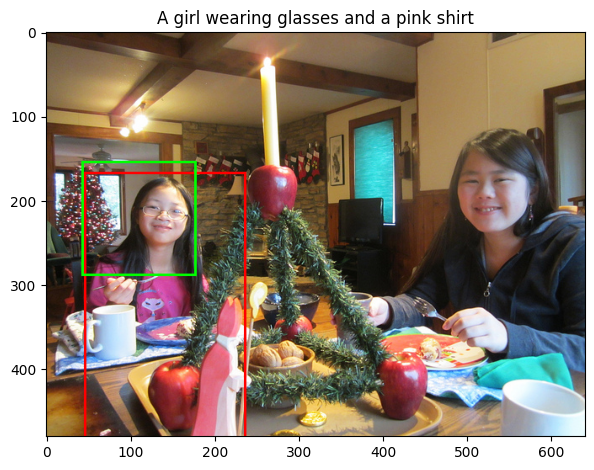

In [59]:
# Show image
plt.title(text)
plt.imshow(image.permute(1,2,0))
plt.tight_layout()
plt.show()

IMPLEMENTAZIONE CON BATCH = 1

In [60]:
# from __future__ import  absolute_import
# import os
# from collections import namedtuple
# import time
# from torch.nn import functional as F
# #from model.utils.creator_tool import AnchorTargetCreator, ProposalTargetCreator

# # from torch import nn
# # import torch as t
# #from utils import array_tool as at
# #from utils.vis_tool import Visualizer

# #from utils.config import opt
# #from torchnet.meter import ConfusionMeter, AverageValueMeter

# LossTuple = namedtuple('LossTuple',
#                        ['rpn_loc_loss',
#                         'rpn_cls_loss',
#                         'roi_loc_loss',
#                         'roi_cls_loss',
#                         'total_loss'
#                         ])


# class FasterRCNNTrainer(nn.Module):
#     """wrapper for conveniently training. return losses

#     The losses include:

#     * :obj:`rpn_loc_loss`: The localization loss for \
#         Region Proposal Network (RPN).
#     * :obj:`rpn_cls_loss`: The classification loss for RPN.
#     * :obj:`roi_loc_loss`: The localization loss for the head module.
#     * :obj:`roi_cls_loss`: The classification loss for the head module.
#     * :obj:`total_loss`: The sum of 4 loss above.

#     Args:
#         faster_rcnn (model.FasterRCNN):
#             A Faster R-CNN model that is going to be trained.
#     """

#     def __init__(self, faster_rcnn):
#         super(FasterRCNNTrainer, self).__init__()

#         self.faster_rcnn = faster_rcnn
#         self.rpn_sigma = 3.
#         self.roi_sigma = 1.

#         # target creator create gt_bbox gt_label etc as training targets. 
#         self.anchor_target_creator = AnchorTargetCreator()
#         self.proposal_target_creator = ProposalTargetCreator()

#         self.loc_normalize_mean = faster_rcnn.loc_normalize_mean
#         self.loc_normalize_std = faster_rcnn.loc_normalize_std

#         self.optimizer = self.faster_rcnn.get_optimizer()
#         # visdom wrapper
#         #self.vis = Visualizer(env=opt.env)

        
#         # indicators for training status
#         # self.rpn_cm = ConfusionMeter(2)
#         # self.roi_cm = ConfusionMeter(21)
#         # self.meters = {k: AverageValueMeter() for k in LossTuple._fields}  # average loss

#     def forward(self, imgs, bboxes, labels, scale):
#         """Forward Faster R-CNN and calculate losses.

#         Here are notations used.

#         * :math:`N` is the batch size.
#         * :math:`R` is the number of bounding boxes per image.

#         Currently, only :math:`N=1` is supported.

#         Args:
#             imgs (~torch.autograd.Variable): A variable with a batch of images.
#             bboxes (~torch.autograd.Variable): A batch of bounding boxes.
#                 Its shape is :math:`(N, R, 4)`.
#             labels (~torch.autograd..Variable): A batch of labels.
#                 Its shape is :math:`(N, R)`. The background is excluded from
#                 the definition, which means that the range of the value
#                 is :math:`[0, L - 1]`. :math:`L` is the number of foreground
#                 classes.
#             scale (float): Amount of scaling applied to
#                 the raw image during preprocessing.

#         Returns:
#             namedtuple of 5 losses
#         """
#         n = bboxes.shape[0]
#         if n != 1:
#             raise ValueError('Currently only batch size 1 is supported.')

#         _, _, H, W = imgs.shape
#         img_size = (H, W)

#         features = self.faster_rcnn.extractor(imgs)

#         rpn_locs, rpn_scores, rois, roi_indices, anchor = \
#             self.faster_rcnn.rpn(features, img_size, scale)

#         # Since batch size is one, convert variables to singular form
#         bbox = bboxes
#         label = labels
#         rpn_score = rpn_scores[0]
#         rpn_loc = rpn_locs[0]
#         roi = rois

#         # Sample RoIs and forward
#         # it's fine to break the computation graph of rois, 
#         # consider them as constant input
#         sample_roi, gt_roi_loc, gt_roi_label = self.proposal_target_creator(
#             roi,
#             tonumpy(bbox),
#             tonumpy(label),
#             self.loc_normalize_mean,
#             self.loc_normalize_std)
        
#         # NOTE it's all zero because now it only support for batch=1 now
#         sample_roi_index = torch.zeros(len(sample_roi))
#         roi_cls_loc, roi_score = self.faster_rcnn.head(
#             features,
#             sample_roi,
#             sample_roi_index)

#         # ------------------ RPN losses -------------------#
#         gt_rpn_loc, gt_rpn_label = self.anchor_target_creator(
#             tonumpy(bbox),
#             anchor,
#             img_size)
#         gt_rpn_label = totensor(gt_rpn_label).long()
#         gt_rpn_loc = totensor(gt_rpn_loc)
#         rpn_loc_loss = _fast_rcnn_loc_loss(
#             rpn_loc,
#             gt_rpn_loc,
#             gt_rpn_label.data,
#             self.rpn_sigma)

#         # NOTE: default value of ignore_index is -100 ...
#         #rpn_cls_loss = F.cross_entropy(rpn_score, gt_rpn_label.cuda(), ignore_index=-1)
#         rpn_cls_loss = F.cross_entropy(rpn_score, gt_rpn_label, ignore_index=-1)

#         _gt_rpn_label = gt_rpn_label[gt_rpn_label > -1]
#         _rpn_score = tonumpy(rpn_score)[tonumpy(gt_rpn_label) > -1]
#         #self.rpn_cm.add(totensor(_rpn_score, False), _gt_rpn_label.data.long())

#         # ------------------ ROI losses (fast rcnn loss) -------------------#
#         n_sample = roi_cls_loc.shape[0]
        
#         roi_cls_loc = roi_cls_loc.view(n_sample, -1, 4)
        
#         # roi_loc = roi_cls_loc[torch.arange(0, n_sample).long().cuda(), \
#         #                       totensor(gt_roi_label).long()]
#         roi_loc = roi_cls_loc[torch.arange(0, n_sample).long(), \
#                               totensor(gt_roi_label).long()]
#         gt_roi_label = totensor(gt_roi_label).long()
#         gt_roi_loc = totensor(gt_roi_loc)

#         roi_loc_loss = _fast_rcnn_loc_loss(
#             roi_loc.contiguous(),
#             gt_roi_loc,
#             gt_roi_label.data,
#             self.roi_sigma)

#         # roi_cls_loss = nn.CrossEntropyLoss()(roi_score, gt_roi_label.cuda())
#         roi_cls_loss = nn.CrossEntropyLoss()(roi_score, gt_roi_label)

#         #self.roi_cm.add(totensor(roi_score, False), gt_roi_label.data.long())

#         losses = [rpn_loc_loss, rpn_cls_loss, roi_loc_loss, roi_cls_loss]
#         losses = losses + [sum(losses)]

#         return LossTuple(*losses)

#     def train_step(self, imgs, bboxes, labels, scale):
#         self.optimizer.zero_grad()
#         losses = self.forward(imgs, bboxes, labels, scale)
#         losses.total_loss.backward()
#         self.optimizer.step()
#         #self.update_meters(losses)
        
#         return losses

#     # def save(self, save_optimizer=False, save_path=None, **kwargs):
#     #     """serialize models include optimizer and other info
#     #     return path where the model-file is stored.

#     #     Args:
#     #         save_optimizer (bool): whether save optimizer.state_dict().
#     #         save_path (string): where to save model, if it's None, save_path
#     #             is generate using time str and info from kwargs.
        
#     #     Returns:
#     #         save_path(str): the path to save models.
#     #     """
#     #     save_dict = dict()

#     #     save_dict['model'] = self.faster_rcnn.state_dict()
#     #     save_dict['config'] = opt._state_dict()
#     #     save_dict['other_info'] = kwargs
#     #     save_dict['vis_info'] = self.vis.state_dict()

#     #     if save_optimizer:
#     #         save_dict['optimizer'] = self.optimizer.state_dict()

#     #     if save_path is None:
#     #         timestr = time.strftime('%m%d%H%M')
#     #         save_path = 'checkpoints/fasterrcnn_%s' % timestr
#     #         for k_, v_ in kwargs.items():
#     #             save_path += '_%s' % v_

#     #     save_dir = os.path.dirname(save_path)
#     #     if not os.path.exists(save_dir):
#     #         os.makedirs(save_dir)

#     #     t.save(save_dict, save_path)
#     #     self.vis.save([self.vis.env])
#     #     return save_path

#     # def load(self, path, load_optimizer=True, parse_opt=False, ):
#     #     state_dict = t.load(path)
#     #     if 'model' in state_dict:
#     #         self.faster_rcnn.load_state_dict(state_dict['model'])
#     #     else:  # legacy way, for backward compatibility
#     #         self.faster_rcnn.load_state_dict(state_dict)
#     #         return self
#     #     if parse_opt:
#     #         opt._parse(state_dict['config'])
#     #     if 'optimizer' in state_dict and load_optimizer:
#     #         self.optimizer.load_state_dict(state_dict['optimizer'])
#     #     return self

#     # def update_meters(self, losses):
#     #     loss_d = {k: at.scalar(v) for k, v in losses._asdict().items()}
#     #     for key, meter in self.meters.items():
#     #         meter.add(loss_d[key])

#     # def reset_meters(self):
#     #     for key, meter in self.meters.items():
#     #         meter.reset()
#     #     self.roi_cm.reset()
#     #     self.rpn_cm.reset()

#     # def get_meter_data(self):
#     #     return {k: v.value()[0] for k, v in self.meters.items()}


# def _smooth_l1_loss(x, t, in_weight, sigma):
#     sigma2 = sigma ** 2
#     diff = in_weight * (x - t)
#     abs_diff = diff.abs()
#     flag = (abs_diff.data < (1. / sigma2)).float()
#     y = (flag * (sigma2 / 2.) * (diff ** 2) +
#          (1 - flag) * (abs_diff - 0.5 / sigma2))
#     return y.sum()


# def _fast_rcnn_loc_loss(pred_loc, gt_loc, gt_label, sigma):
#     # in_weight = torch.zeros(gt_loc.shape).cuda()
#     in_weight = torch.zeros(gt_loc.shape)
#     # Localization loss is calculated only for positive rois.
#     # NOTE:  unlike origin implementation, 
#     # we don't need inside_weight and outside_weight, they can calculate by gt_label
#     # in_weight[(gt_label > 0).view(-1, 1).expand_as(in_weight).cuda()] = 1
#     in_weight[(gt_label > 0).view(-1, 1).expand_as(in_weight)] = 1
#     loc_loss = _smooth_l1_loss(pred_loc, gt_loc, in_weight.detach(), sigma)
#     # Normalize by total number of negtive and positive rois.
#     loc_loss /= ((gt_label >= 0).sum().float()) # ignore gt_label==-1 for rpn_loss
#     return loc_loss

TENTATIVO IMPLEMENTAZIONE PER BATCH > 1

In [41]:
from __future__ import  absolute_import
import os
from collections import namedtuple
import time
from torch.nn import functional as F
#from model.utils.creator_tool import AnchorTargetCreator, ProposalTargetCreator

# from torch import nn
# import torch as t
#from utils import array_tool as at
#from utils.vis_tool import Visualizer

#from utils.config import opt
#from torchnet.meter import ConfusionMeter, AverageValueMeter

LossTuple = namedtuple('LossTuple',
                       ['rpn_loc_loss_batch',
                        'rpn_cls_loss_batch',
                        'roi_loc_loss_batch',
                        'roi_cls_loss_batch',
                        'clip_loss_batch',
                        'total_loss'
                        ])


class FasterRCNNTrainer(nn.Module):
    """wrapper for conveniently training. return losses

    The losses include:

    * :obj:`rpn_loc_loss`: The localization loss for \
        Region Proposal Network (RPN).
    * :obj:`rpn_cls_loss`: The classification loss for RPN.
    * :obj:`roi_loc_loss`: The localization loss for the head module.
    * :obj:`roi_cls_loss`: The classification loss for the head module.
    * :obj:`total_loss`: The sum of 4 loss above.

    Args:
        faster_rcnn (model.FasterRCNN):
            A Faster R-CNN model that is going to be trained.
    """

    def __init__(self, faster_rcnn, clip_model, clip_preprocess):
        super(FasterRCNNTrainer, self).__init__()

        self.faster_rcnn = faster_rcnn
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess
        
        
        self.rpn_sigma = 3.
        self.roi_sigma = 1.

        # target creator create gt_bbox gt_label etc as training targets. 
        self.anchor_target_creator = AnchorTargetCreator()
        self.proposal_target_creator = ProposalTargetCreator()

        self.loc_normalize_mean = faster_rcnn.loc_normalize_mean
        self.loc_normalize_std = faster_rcnn.loc_normalize_std

        self.optimizer = self.faster_rcnn.get_optimizer()
        # visdom wrapper
        #self.vis = Visualizer(env=opt.env)

        
        # indicators for training status
        # self.rpn_cm = ConfusionMeter(2)
        # self.roi_cm = ConfusionMeter(21)
        # self.meters = {k: AverageValueMeter() for k in LossTuple._fields}  # average loss

    def forward(self, texts, imgs, bboxes, labels, scales):
        """Forward Faster R-CNN and calculate losses.

        Here are notations used.

        * :math:`N` is the batch size.
        * :math:`R` is the number of bounding boxes per image.

        Currently, only :math:`N=1` is supported.

        Args:
            imgs (~torch.autograd.Variable): A variable with a batch of images.
            bboxes (~torch.autograd.Variable): A batch of bounding boxes.
                Its shape is :math:`(N, R, 4)`.
            labels (~torch.autograd..Variable): A batch of labels.
                Its shape is :math:`(N, R)`. The background is excluded from
                the definition, which means that the range of the value
                is :math:`[0, L - 1]`. :math:`L` is the number of foreground
                classes.
            scale (float): Amount of scaling applied to
                the raw image during preprocessing.

        Returns:
            namedtuple of 5 losses
        """
        n = bboxes.shape[0]
        # if n != 1:
        #     raise ValueError('Currently only batch size 1 is supported.')
        
        rpn_cls_loss_batch = 0.0
        roi_loc_loss_batch = 0.0
        roi_cls_loss_batch = 0.0
        rpn_loc_loss_batch = 0.0
        clip_loss_batch = 0.0
        
        for i in (range(n)):
            
            bbox = bboxes[i]
            bbox = bbox.unsqueeze(0)
            label = labels
            img = imgs[i]
            scale = scales[i]
            text = texts[i]
            
            img = img.unsqueeze(0)
            scale = scalar(scale)
            
            _, _, H, W = img.shape
            img_size = (H, W)

            features = self.faster_rcnn.extractor(img)

            rpn_locs, rpn_scores, rois, roi_indices, anchor = \
                self.faster_rcnn.rpn(features, img_size, scale)

            
            # Since batch size is one, convert variables to singular form
            # rpn_score = rpn_scores[i]
            # rpn_loc = rpn_locs[i]
            # roi = rois[i]

            # Sample RoIs and forward
            # it's fine to break the computation graph of rois, 
            # consider them as constant input
            
            
            sample_roi, gt_roi_loc, gt_roi_label = self.proposal_target_creator(
                rois,
                tonumpy(bbox),
                tonumpy(label),
                self.loc_normalize_mean,
                self.loc_normalize_std)
            
            # NOTE it's all zero because now it only support for batch=1 now
            sample_roi_index = torch.zeros(len(sample_roi))
            roi_cls_loc, roi_score = self.faster_rcnn.head(
                features,
                sample_roi,
                sample_roi_index)

            # ------------------ RPN losses -------------------#
            gt_rpn_loc, gt_rpn_label = self.anchor_target_creator(
                tonumpy(bbox),
                anchor,
                img_size)
            gt_rpn_label = totensor(gt_rpn_label).long()
            gt_rpn_loc = totensor(gt_rpn_loc)
            rpn_loc_loss = _fast_rcnn_loc_loss(
                rpn_locs,
                gt_rpn_loc,
                gt_rpn_label.data,
                self.rpn_sigma)

            # NOTE: default value of ignore_index is -100 ...
            #rpn_cls_loss = F.cross_entropy(rpn_score, gt_rpn_label.cuda(), ignore_index=-1)
            
            rpn_scores = rpn_scores.squeeze(0)
            
            rpn_cls_loss = F.cross_entropy(rpn_scores, gt_rpn_label, ignore_index=-1)

            _gt_rpn_label = gt_rpn_label[gt_rpn_label > -1]
            _rpn_score = tonumpy(rpn_scores)[tonumpy(gt_rpn_label) > -1]
            #self.rpn_cm.add(totensor(_rpn_score, False), _gt_rpn_label.data.long())

            # ------------------ ROI losses (fast rcnn loss) -------------------#
            n_sample = roi_cls_loc.shape[0]
            
            roi_cls_loc = roi_cls_loc.view(n_sample, -1, 4)
            
            # roi_loc = roi_cls_loc[torch.arange(0, n_sample).long().cuda(), \
            #                       totensor(gt_roi_label).long()]
            roi_loc = roi_cls_loc[torch.arange(0, n_sample).long(), \
                                totensor(gt_roi_label).long()]
            gt_roi_label = totensor(gt_roi_label).long()
            gt_roi_loc = totensor(gt_roi_loc)

            roi_loc_loss = _fast_rcnn_loc_loss(
                roi_loc.contiguous(),
                gt_roi_loc,
                gt_roi_label.data,
                self.roi_sigma)

            # roi_cls_loss = nn.CrossEntropyLoss()(roi_score, gt_roi_label.cuda())
            roi_cls_loss = nn.CrossEntropyLoss()(roi_score, gt_roi_label)

            rpn_cls_loss_batch += rpn_cls_loss
            roi_loc_loss_batch += roi_loc_loss
            roi_cls_loss_batch += roi_cls_loss
            rpn_loc_loss_batch += rpn_loc_loss
            
            # ------------------ CLIP loss -------------------#
            # Prepara l'immagine per CLIP (usa il preprocessore)
            #image_input = clip.preprocess(img).unsqueeze(0).to(self.device)  # Preprocessa l'immagine
            image_features = self.clip_model.encode_image(img)  # Estrai le caratteristiche dell'immagine

            # Prepara il testo per CLIP (usa il preprocessore)
            #text_input = clip.tokenize(texts).to(self.device)  # Preprocessa il testo
            text_features = self.clip_model.encode_text(text)  # Estrai le caratteristiche del testo

            # Calcola la similarità cosine tra l'immagine e il testo
            similarity = F.cosine_similarity(image_features, text_features)

            # Perdita CLIP: penalizzare la dissimilarità
            clip_loss = 1 - similarity.mean()  # Minimizzare la dissimilarità media
            clip_loss_batch += clip_loss

        # Normalizza le perdite per il batch
        rpn_loc_loss_batch /= n
        rpn_cls_loss_batch /= n
        roi_loc_loss_batch /= n
        roi_cls_loss_batch /= n
        clip_loss_batch /= n 
        
        #self.roi_cm.add(totensor(roi_score, False), gt_roi_label.data.long())

        losses = [rpn_loc_loss_batch, rpn_cls_loss_batch, roi_loc_loss_batch, roi_cls_loss_batch]
        losses = losses + [clip_loss_batch]
        losses = losses + [sum(losses)]

        return LossTuple(*losses)

    def train_step(self, texts, imgs, bboxes, labels, scale):
        self.faster_rcnn.train()
        self.optimizer.zero_grad()
        losses = self.forward(texts, imgs, bboxes, labels, scale)
        losses.total_loss.backward()
        self.optimizer.step()
        #self.update_meters(losses)
        
        return losses
    
    def eval_step(self, texts, imgs, bboxes, labels, scale):
        
        self.faster_rcnn.eval()
        
        with torch.no_grad():  # Disabilita il calcolo del gradiente
            losses = self.forward(texts, imgs, bboxes, labels, scale)
        
        return losses

    # def save(self, save_optimizer=False, save_path=None, **kwargs):
    #     """serialize models include optimizer and other info
    #     return path where the model-file is stored.

    #     Args:
    #         save_optimizer (bool): whether save optimizer.state_dict().
    #         save_path (string): where to save model, if it's None, save_path
    #             is generate using time str and info from kwargs.
        
    #     Returns:
    #         save_path(str): the path to save models.
    #     """
    #     save_dict = dict()

    #     save_dict['model'] = self.faster_rcnn.state_dict()
    #     save_dict['config'] = opt._state_dict()
    #     save_dict['other_info'] = kwargs
    #     save_dict['vis_info'] = self.vis.state_dict()

    #     if save_optimizer:
    #         save_dict['optimizer'] = self.optimizer.state_dict()

    #     if save_path is None:
    #         timestr = time.strftime('%m%d%H%M')
    #         save_path = 'checkpoints/fasterrcnn_%s' % timestr
    #         for k_, v_ in kwargs.items():
    #             save_path += '_%s' % v_

    #     save_dir = os.path.dirname(save_path)
    #     if not os.path.exists(save_dir):
    #         os.makedirs(save_dir)

    #     t.save(save_dict, save_path)
    #     self.vis.save([self.vis.env])
    #     return save_path

    # def load(self, path, load_optimizer=True, parse_opt=False, ):
    #     state_dict = t.load(path)
    #     if 'model' in state_dict:
    #         self.faster_rcnn.load_state_dict(state_dict['model'])
    #     else:  # legacy way, for backward compatibility
    #         self.faster_rcnn.load_state_dict(state_dict)
    #         return self
    #     if parse_opt:
    #         opt._parse(state_dict['config'])
    #     if 'optimizer' in state_dict and load_optimizer:
    #         self.optimizer.load_state_dict(state_dict['optimizer'])
    #     return self

    # def update_meters(self, losses):
    #     loss_d = {k: at.scalar(v) for k, v in losses._asdict().items()}
    #     for key, meter in self.meters.items():
    #         meter.add(loss_d[key])

    # def reset_meters(self):
    #     for key, meter in self.meters.items():
    #         meter.reset()
    #     self.roi_cm.reset()
    #     self.rpn_cm.reset()

    # def get_meter_data(self):
    #     return {k: v.value()[0] for k, v in self.meters.items()}


def _smooth_l1_loss(x, t, in_weight, sigma):
    sigma2 = sigma ** 2
    diff = in_weight * (x - t)
    abs_diff = diff.abs()
    flag = (abs_diff.data < (1. / sigma2)).float()
    y = (flag * (sigma2 / 2.) * (diff ** 2) +
         (1 - flag) * (abs_diff - 0.5 / sigma2))
    return y.sum()


def _fast_rcnn_loc_loss(pred_loc, gt_loc, gt_label, sigma):
    # in_weight = torch.zeros(gt_loc.shape).cuda()
    in_weight = torch.zeros(gt_loc.shape)
    # Localization loss is calculated only for positive rois.
    # NOTE:  unlike origin implementation, 
    # we don't need inside_weight and outside_weight, they can calculate by gt_label
    # in_weight[(gt_label > 0).view(-1, 1).expand_as(in_weight).cuda()] = 1
    in_weight[(gt_label > 0).view(-1, 1).expand_as(in_weight)] = 1
    loc_loss = _smooth_l1_loss(pred_loc, gt_loc, in_weight.detach(), sigma)
    # Normalize by total number of negtive and positive rois.
    loc_loss /= ((gt_label >= 0).sum().float()) # ignore gt_label==-1 for rpn_loss
    return loc_loss

In [40]:
epochs = 200
lr_ = 1e-3

In [39]:
iou_threshold = 0.5
loss_meter = MetricMeter(name = 'TrainingEA', threshold=iou_threshold)

In [78]:
def train():
    
    faster_rcnn = FasterRCNNResNet50()
    clip_model, clip_preprocess = clip.load("RN50", device='cpu')
    print('model construct completed')
    trainer = FasterRCNNTrainer(faster_rcnn, clip_model, clip_preprocess)#.cuda()
    
    
    
    best_map = 0
    
    for epoch in tqdm(range(epochs)):
        #trainer.reset_meters()
        for ii, (raw, text, bbox, label, filename, img, scale) in (enumerate(dataloader_train)):
            
            #img, bbox, label = img.cuda().float(), bbox_.cuda(), label_.cuda()
            train_loss = trainer.train_step(text, img, bbox, label, scale)
            print(f'epoch: {epoch}, iter: {epoch + 1}, training loss: {train_loss.total_loss}')
            
        # Let's compute the eval step evry 5 iterations
        if ((epoch + 1)%5) == 0:
            for (raw, text, bbox, label, filename, img, scale) in dataloader_eval:
                eval_loss = trainer.eval_step(text, img, bbox, label, scale)
                print(f'epoch: {epoch + 1 }, iter: {ii}, evaluation loss: {eval_loss.total_loss}')
                
        
            
    

In [77]:
train()

model construct completed


  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [66]:
# def train():
    
#     faster_rcnn = FasterRCNNResNet50()
#     print('model construct completed')
#     trainer = FasterRCNNTrainer(faster_rcnn)#.cuda()
    
    
    
#     best_map = 0
    
#     for epoch in range(epochs):
#         #trainer.reset_meters()
#         for ii, (text, bbox, label, filename, img, scale) in tqdm(enumerate(dataloader_train)):
#             scale = scalar(scale)
#             #img, bbox, label = img.cuda().float(), bbox_.cuda(), label_.cuda()
#             loss = trainer.train_step(img, bbox, label, scale)
#             print("TOTAL LOSS: ", loss.total_loss)
            # if (ii + 1) % opt.plot_every == 0:
            #     if os.path.exists(opt.debug_file):
            #         ipdb.set_trace()

            #     # plot loss
            #     trainer.vis.plot_many(trainer.get_meter_data())

            #     # plot groud truth bboxes
            #     ori_img_ = inverse_normalize(at.tonumpy(img[0]))
            #     gt_img = visdom_bbox(ori_img_,
            #                          at.tonumpy(bbox_[0]),
            #                          at.tonumpy(label_[0]))
            #     trainer.vis.img('gt_img', gt_img)

            #     # plot predicti bboxes
            #     _bboxes, _labels, _scores = trainer.faster_rcnn.predict([ori_img_], visualize=True)
            #     pred_img = visdom_bbox(ori_img_,
            #                            at.tonumpy(_bboxes[0]),
            #                            at.tonumpy(_labels[0]).reshape(-1),
            #                            at.tonumpy(_scores[0]))
            #     trainer.vis.img('pred_img', pred_img)

            #     # rpn confusion matrix(meter)
            #     trainer.vis.text(str(trainer.rpn_cm.value().tolist()), win='rpn_cm')
            #     # roi confusion matrix
            #     trainer.vis.img('roi_cm', at.totensor(trainer.roi_cm.conf, False).float())
        # eval_result = eval(test_dataloader, faster_rcnn, test_num=opt.test_num)
        # trainer.vis.plot('test_map', eval_result['map'])
        # lr_ = trainer.faster_rcnn.optimizer.param_groups[0]['lr']
        # log_info = 'lr:{}, map:{},loss:{}'.format(str(lr_),
        #                                           str(eval_result['map']),
        #                                           str(trainer.get_meter_data()))
        # trainer.vis.log(log_info)

        # if eval_result['map'] > best_map:
        #     best_map = eval_result['map']
        #     best_path = trainer.save(best_map=best_map)
        # if epoch == 9:
        #     trainer.load(best_path)
        #     trainer.faster_rcnn.scale_lr(opt.lr_decay)
        #     lr_ = lr_ * opt.lr_decay

        # if epoch == 13: 
        #     break
    